## 1. Load Dataset

In [1]:
import pandas as pd

dataset = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None)

dataset.head(10)

col_names = ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

train = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None, names=col_names)
test = pd.read_csv('dataset/test_FD001.txt', sep=r'\s+', header=None, names=col_names)
rul_true = pd.read_csv('dataset/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

train.info()

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Raihan Maulana\AppData\Local\Temp\ipykernel_4612\180924967.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  dataset = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None)
C:\Users\Raihan Maulana\AppData\Local\Temp\ipykernel_4612\180924967.py:10: SyntaxWarning: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_number   20631 non-null  int64  
 1   time_cycles   20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [2]:
train.head(5)

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
test.head(5)

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


## 2. Validasi Jumlah Unit

In [4]:
train['unit_number'].nunique()

100

## 3. Finding the sensor with clear trend

In [5]:
import matplotlib.pyplot as plt

In [6]:
units = [1, 2, 3]

unit_selected = train[train["unit_number"].isin(units)]

In [7]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

print("Sensors:")
print(sensor_cols)

Sensors:
['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']



Plotting Unit 1...


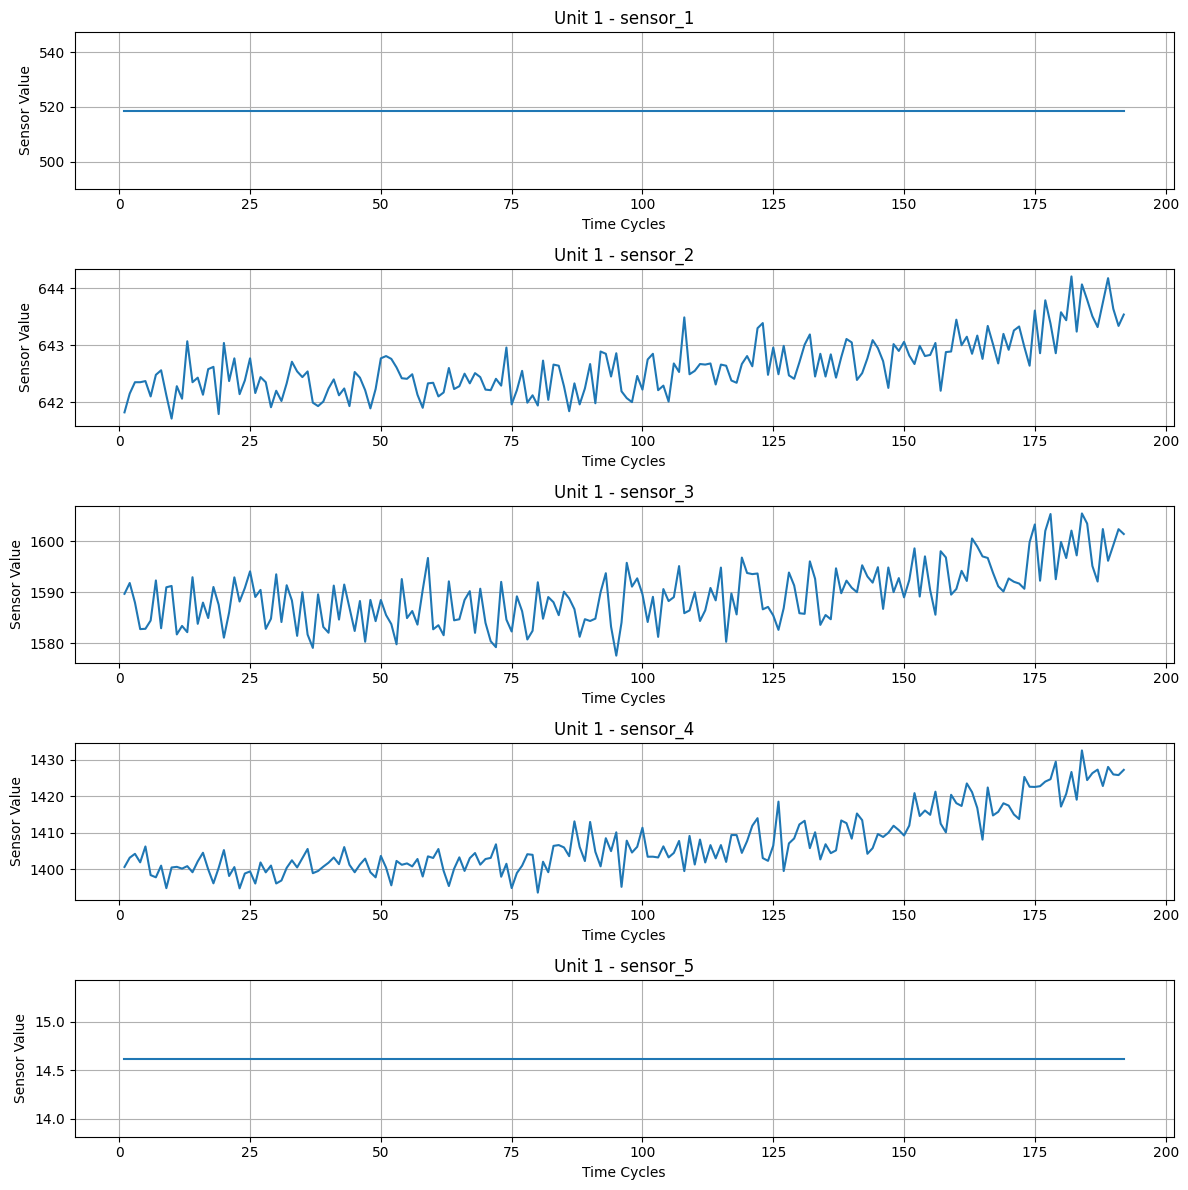

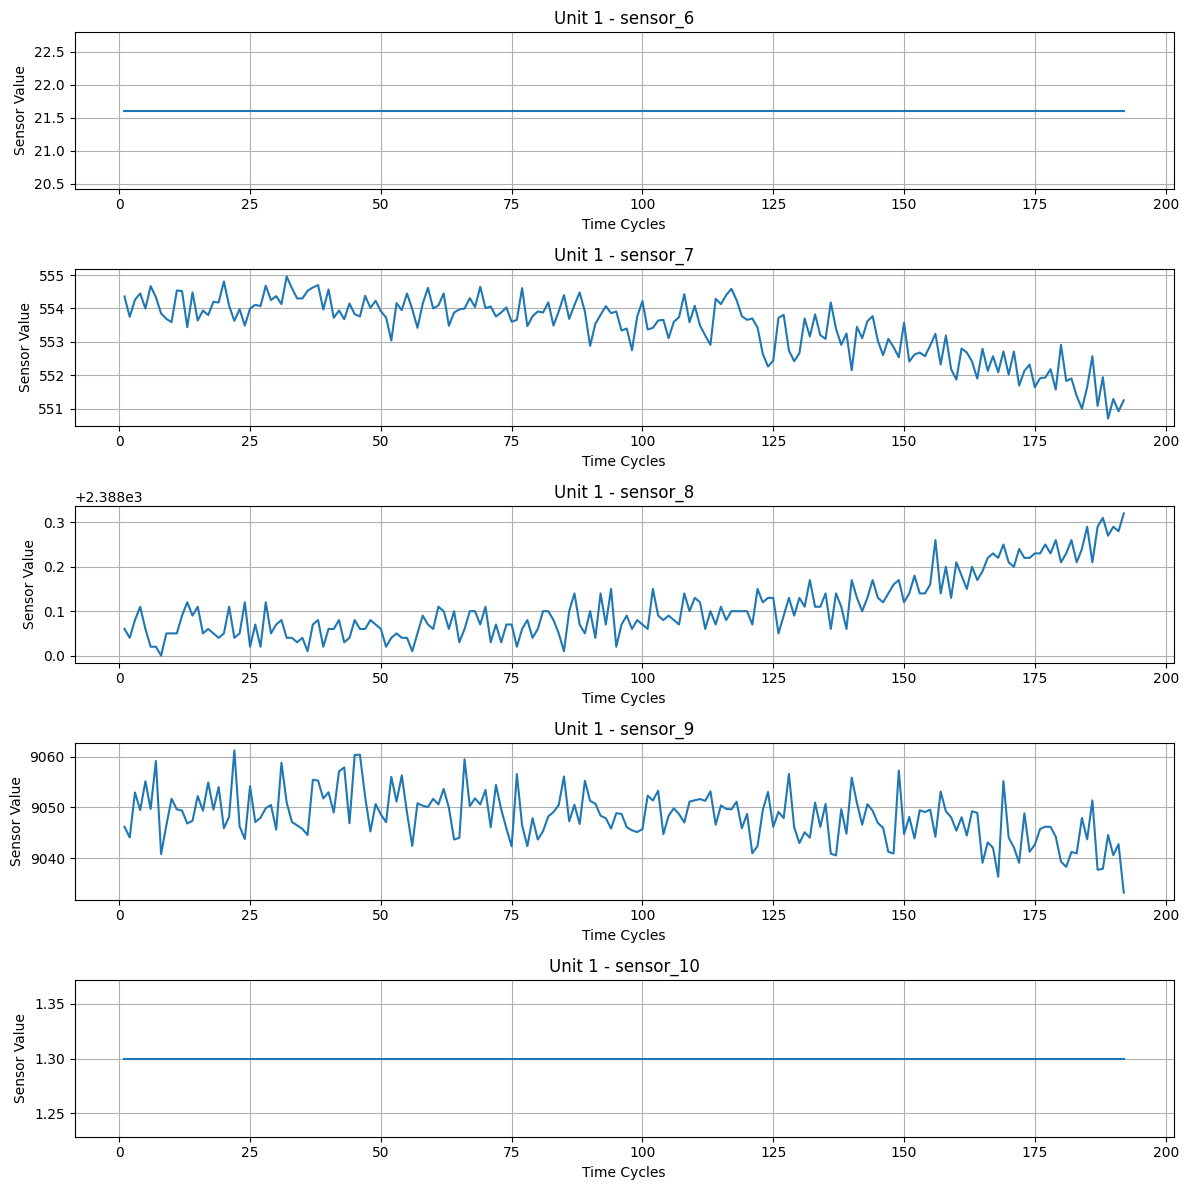

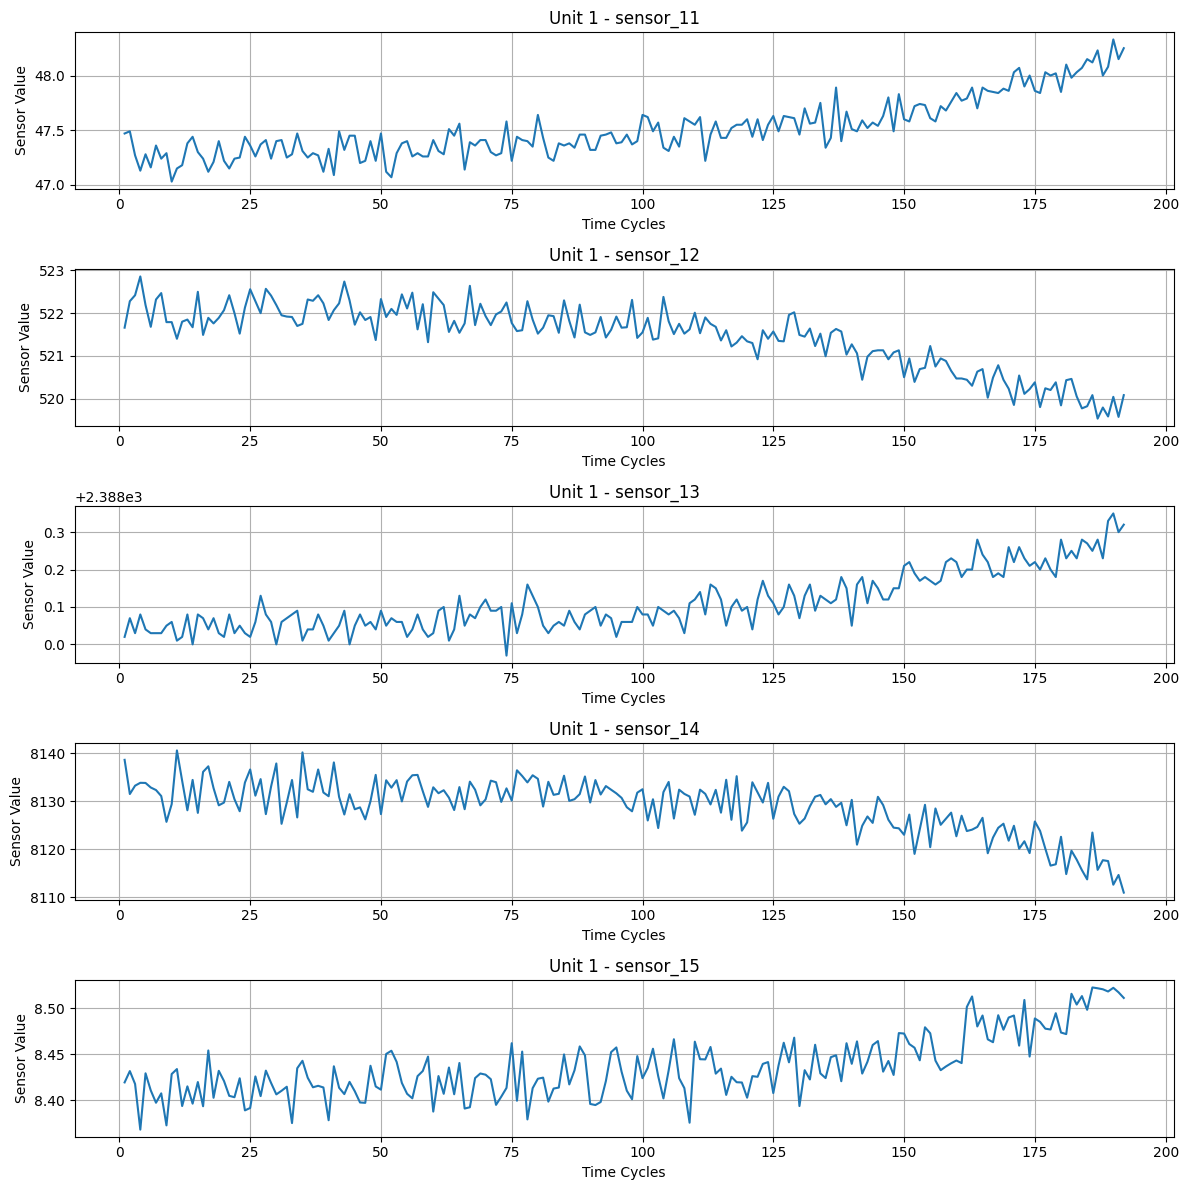

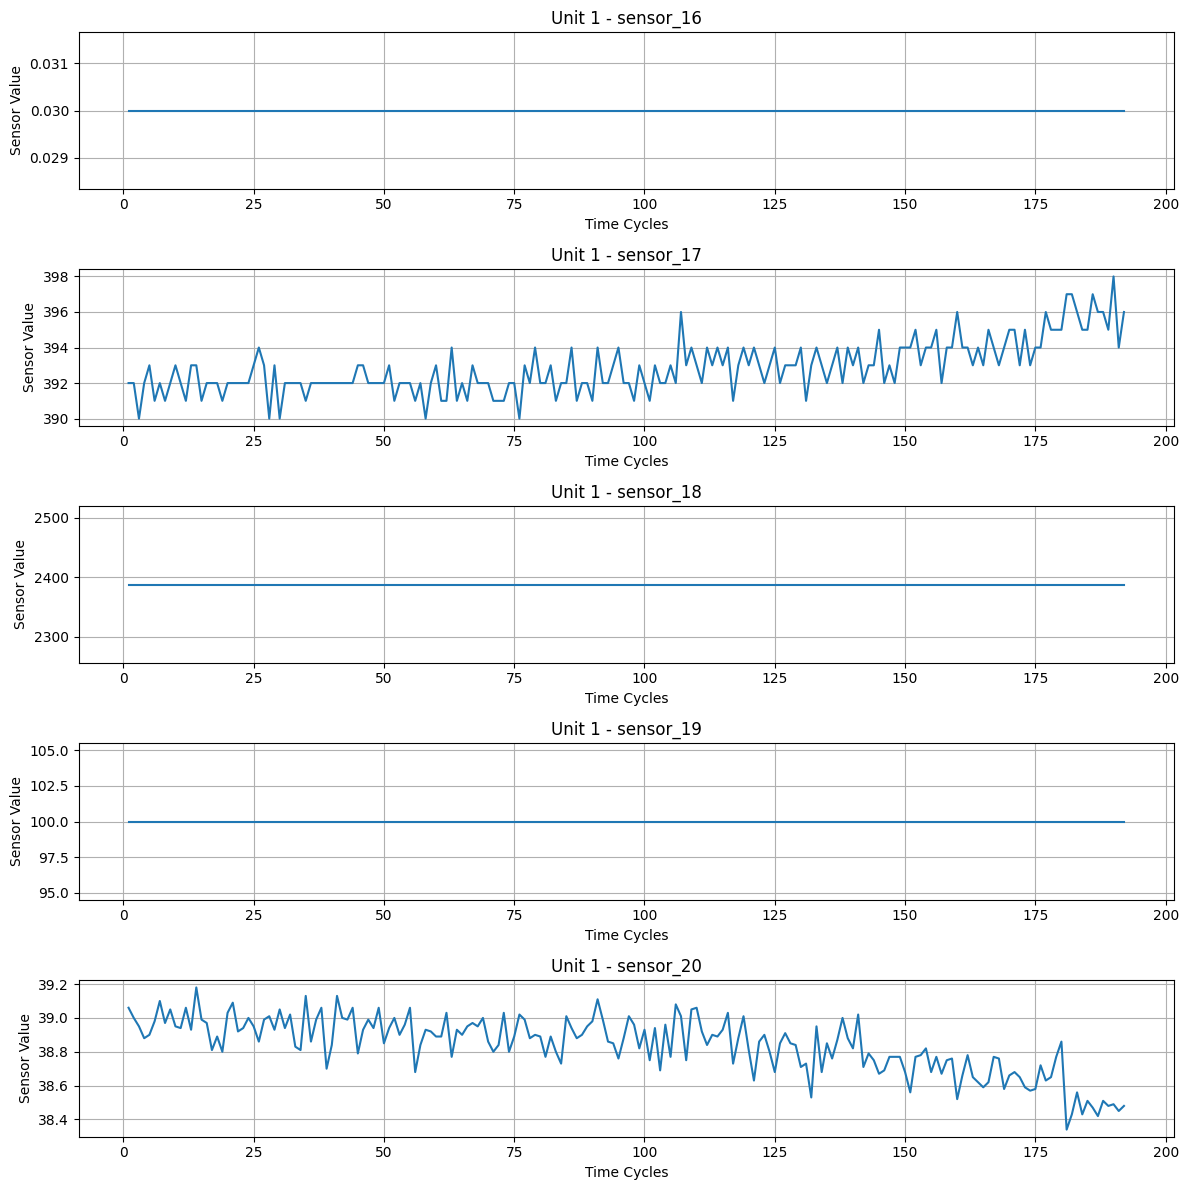

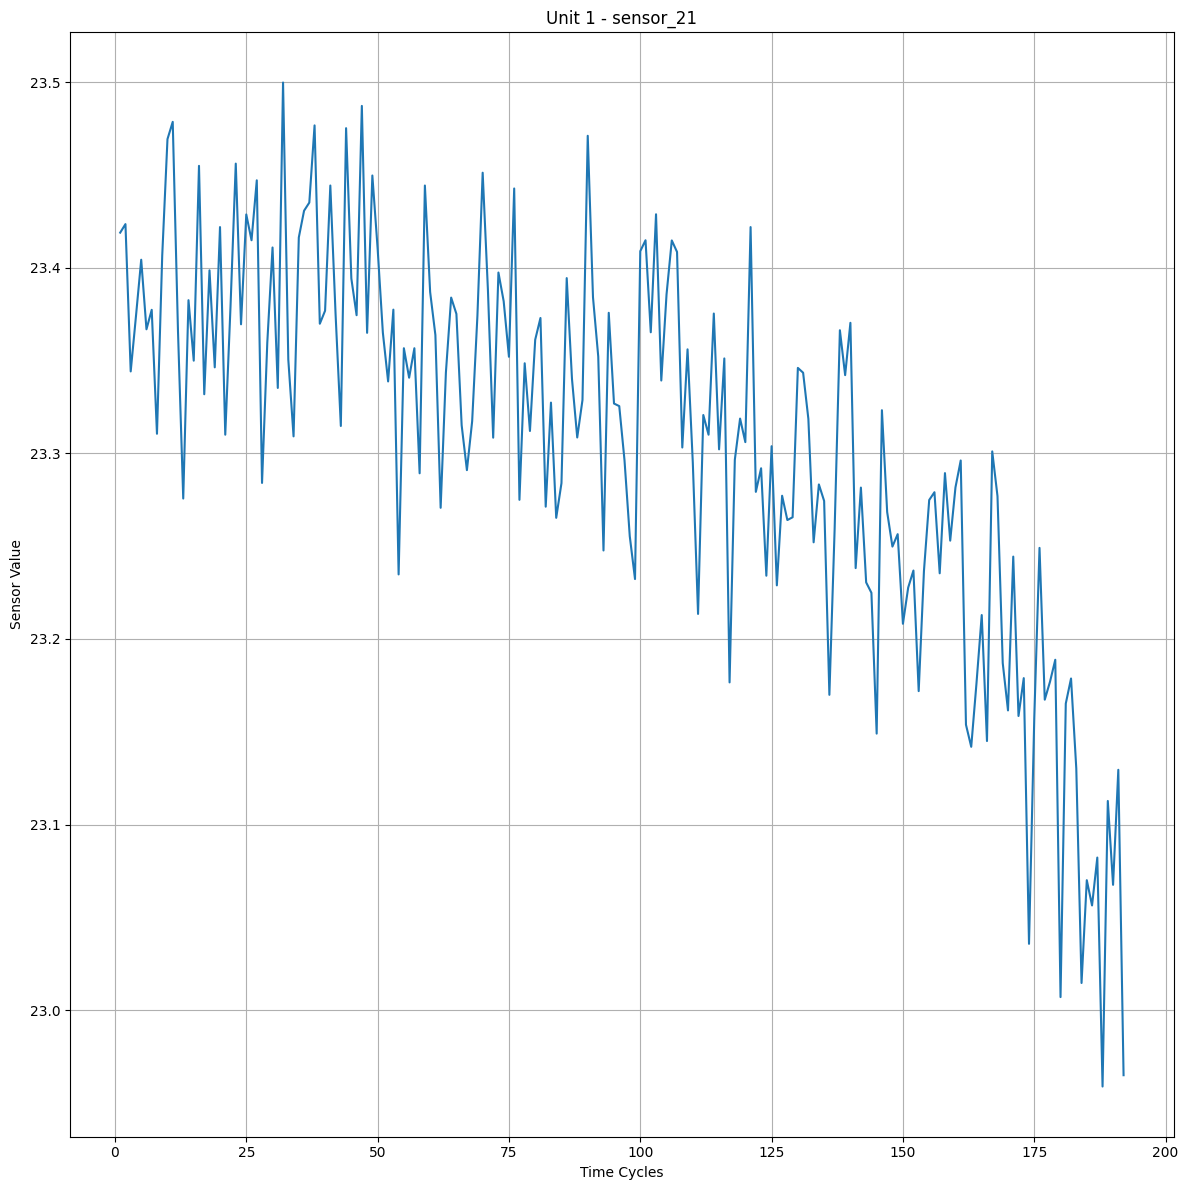


Plotting Unit 2...


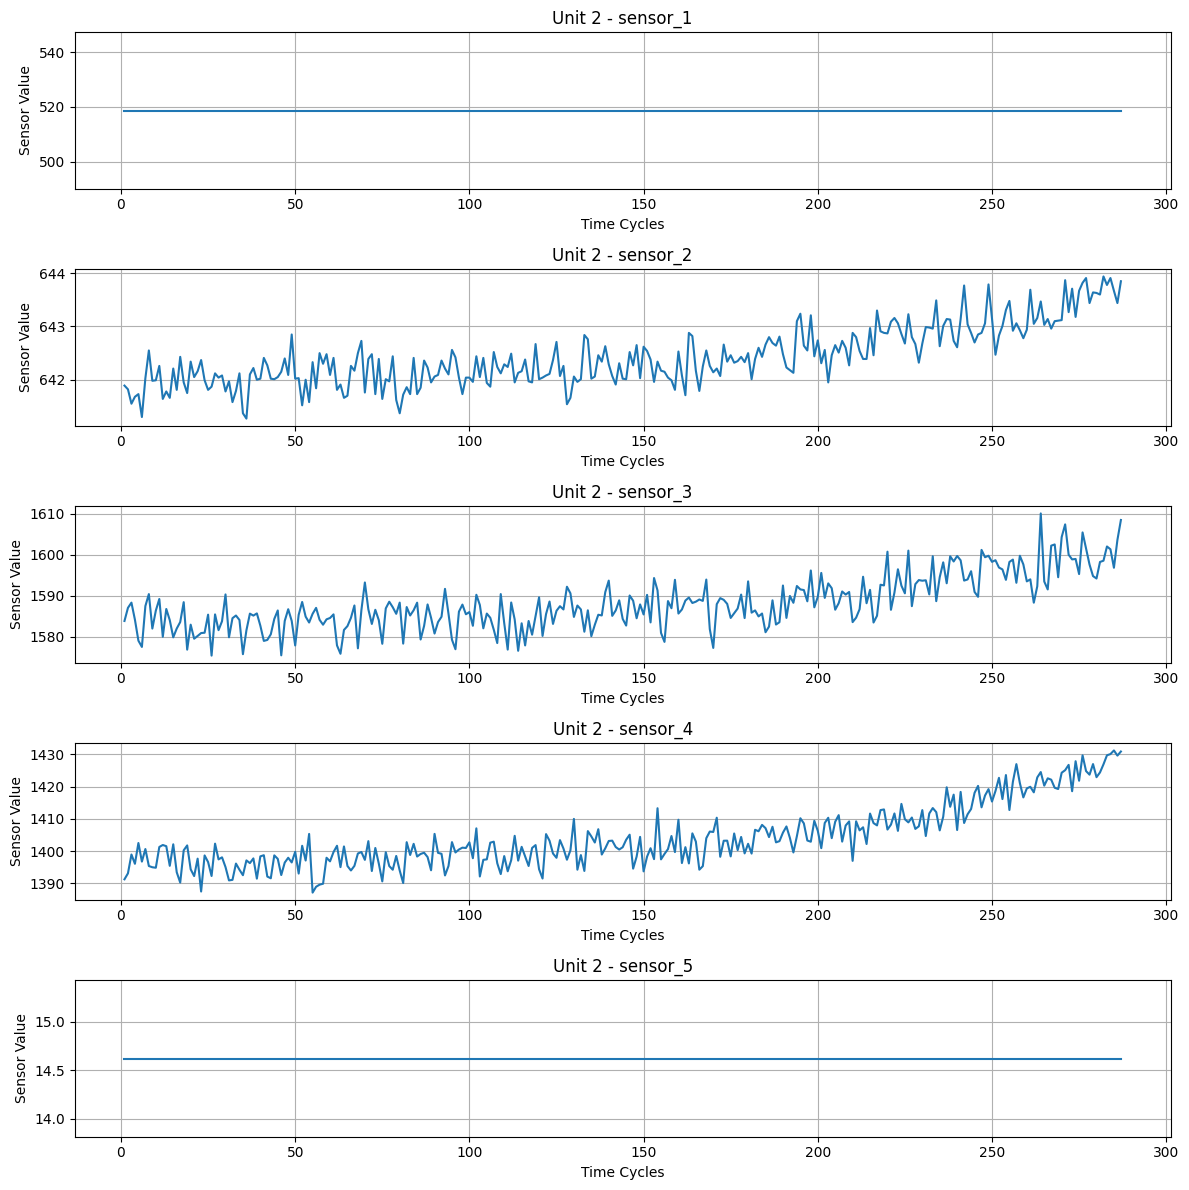

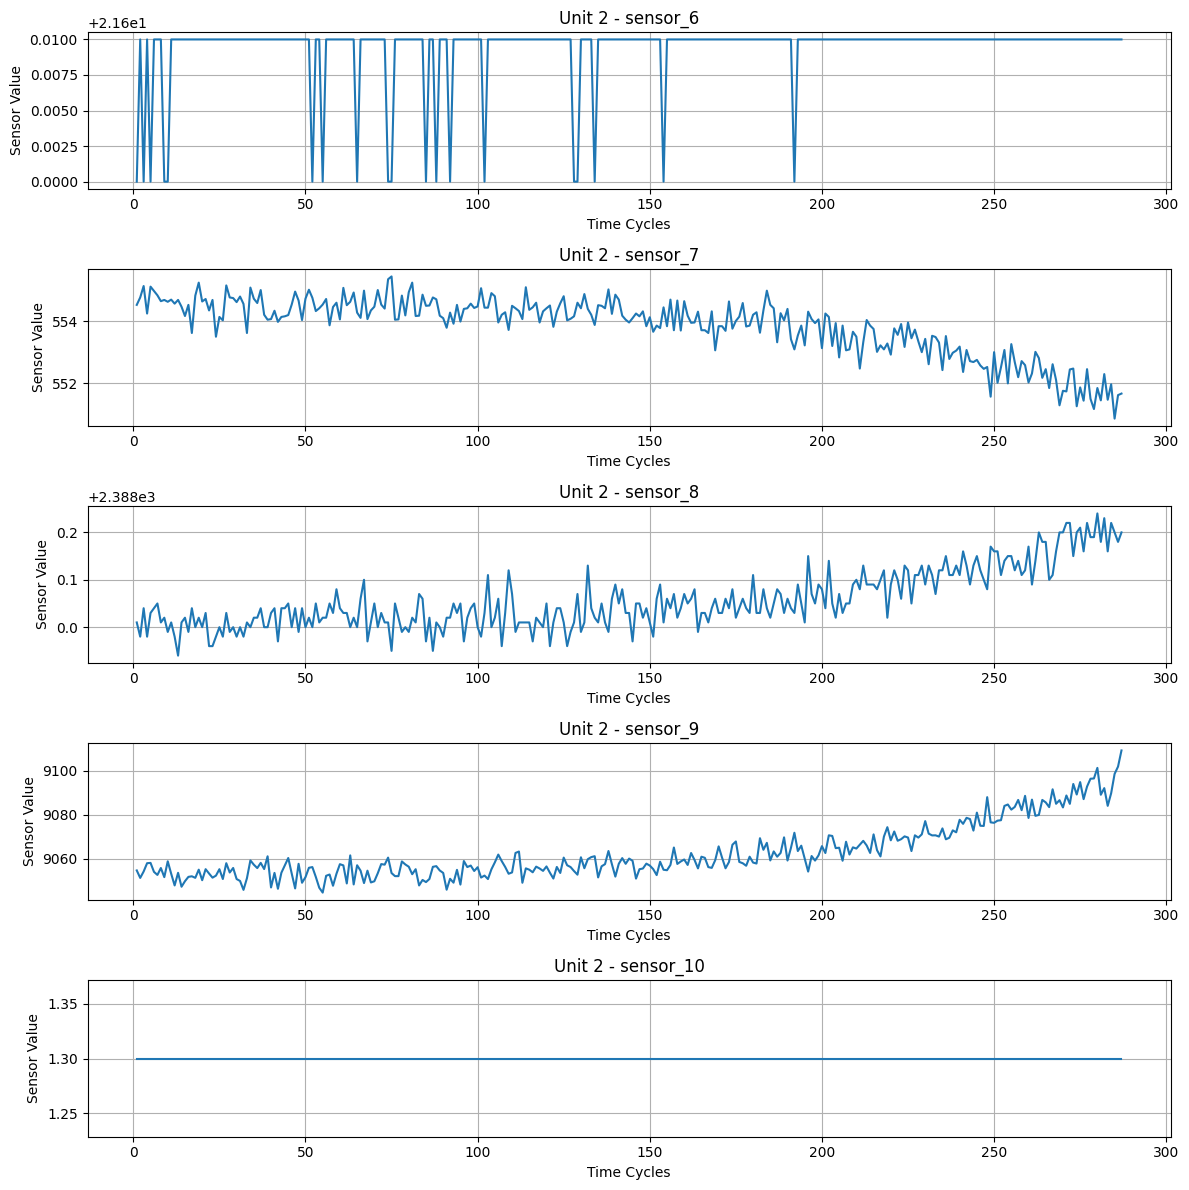

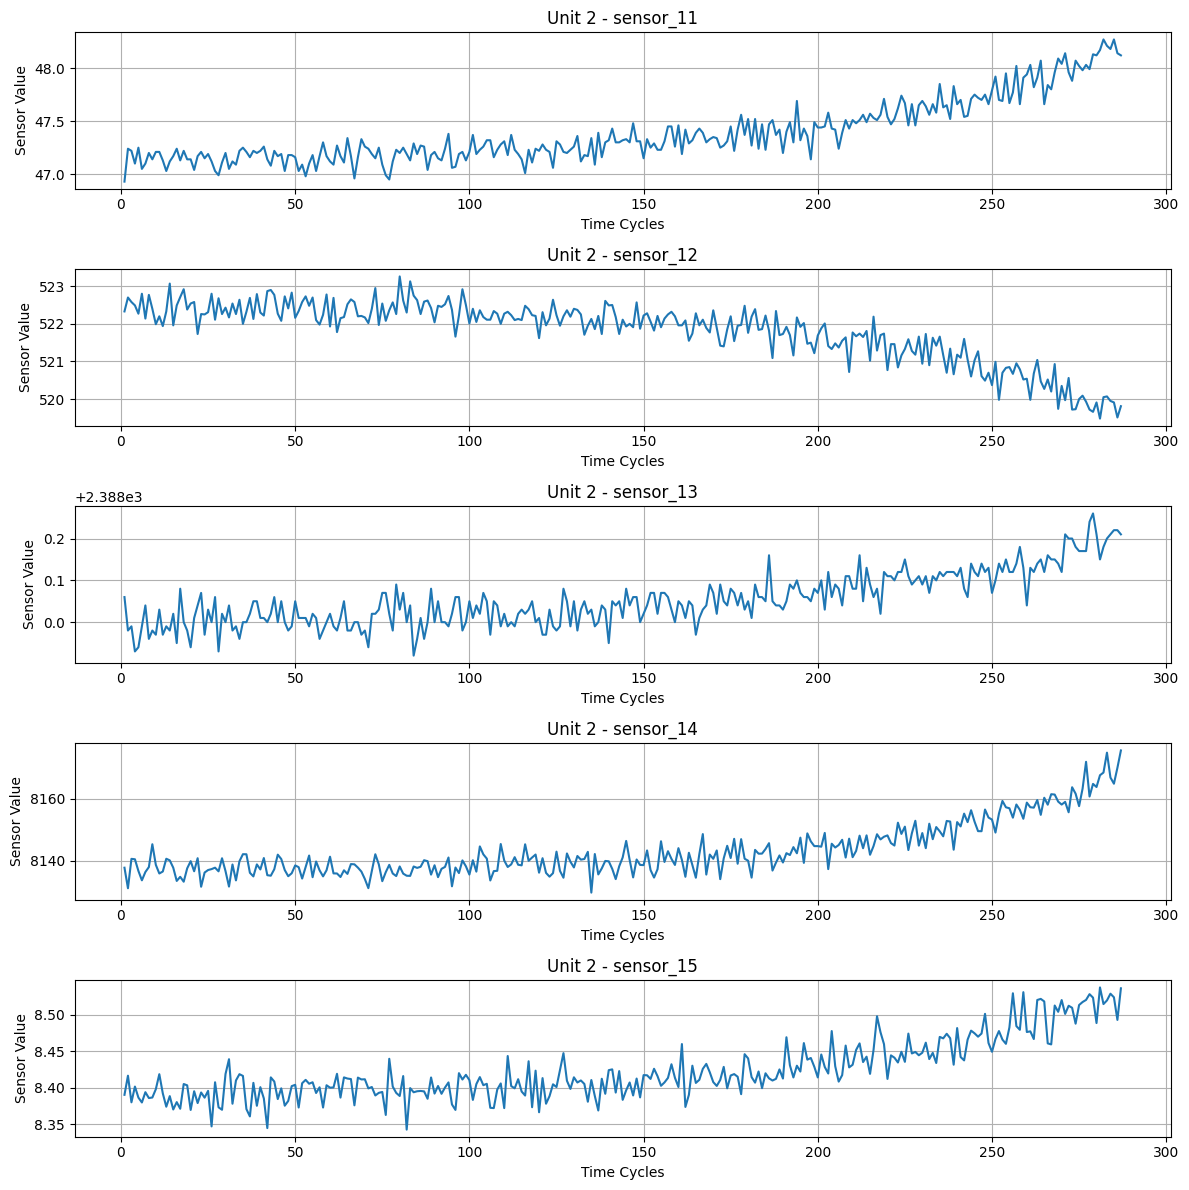

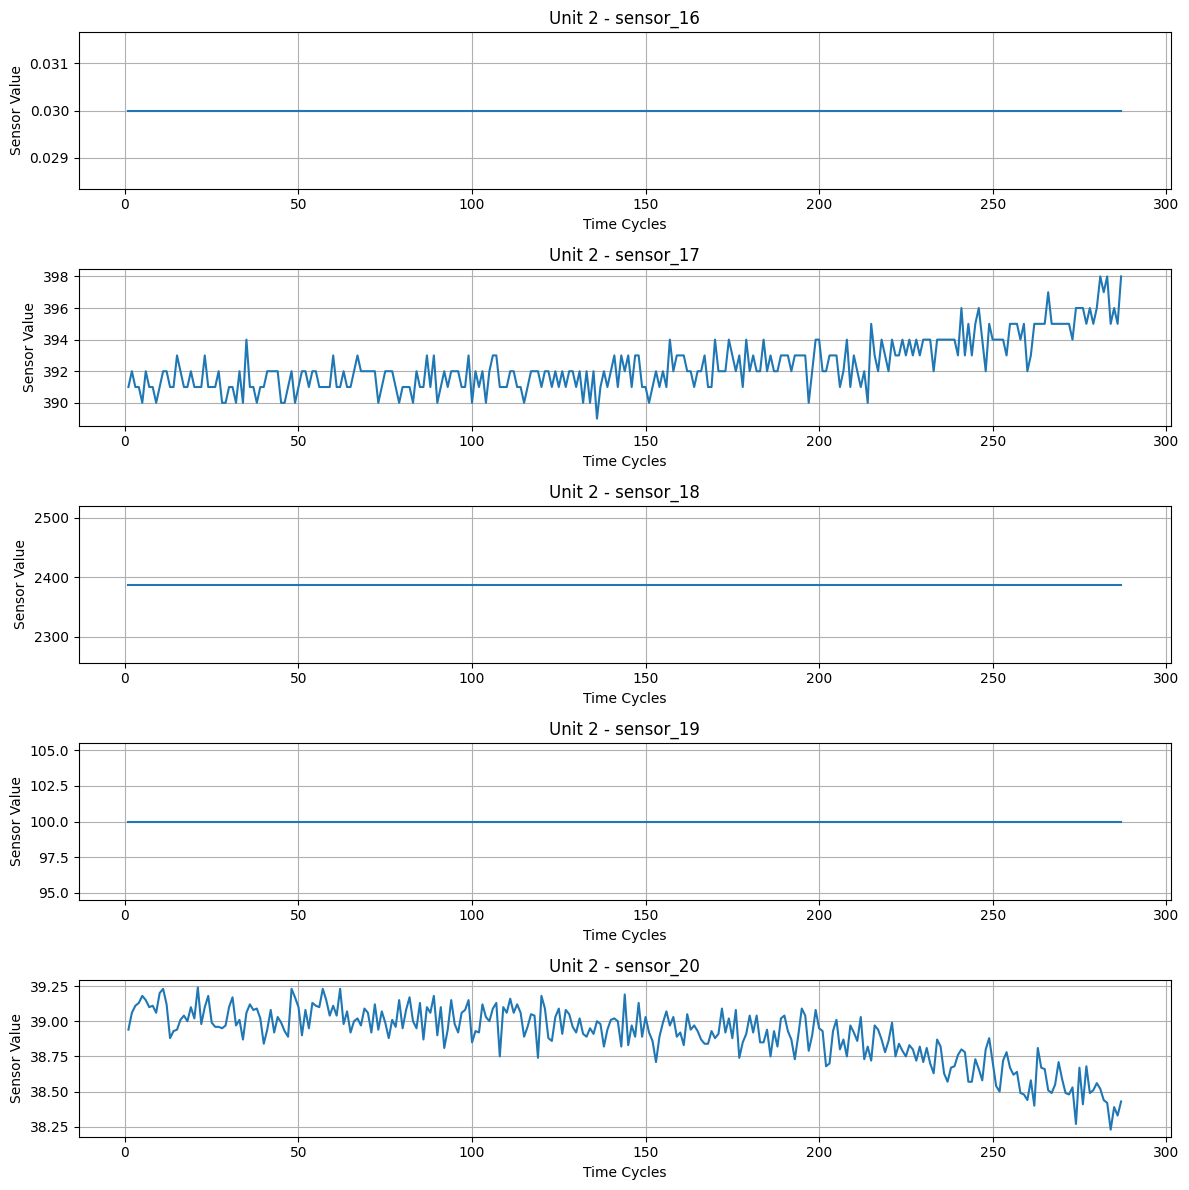

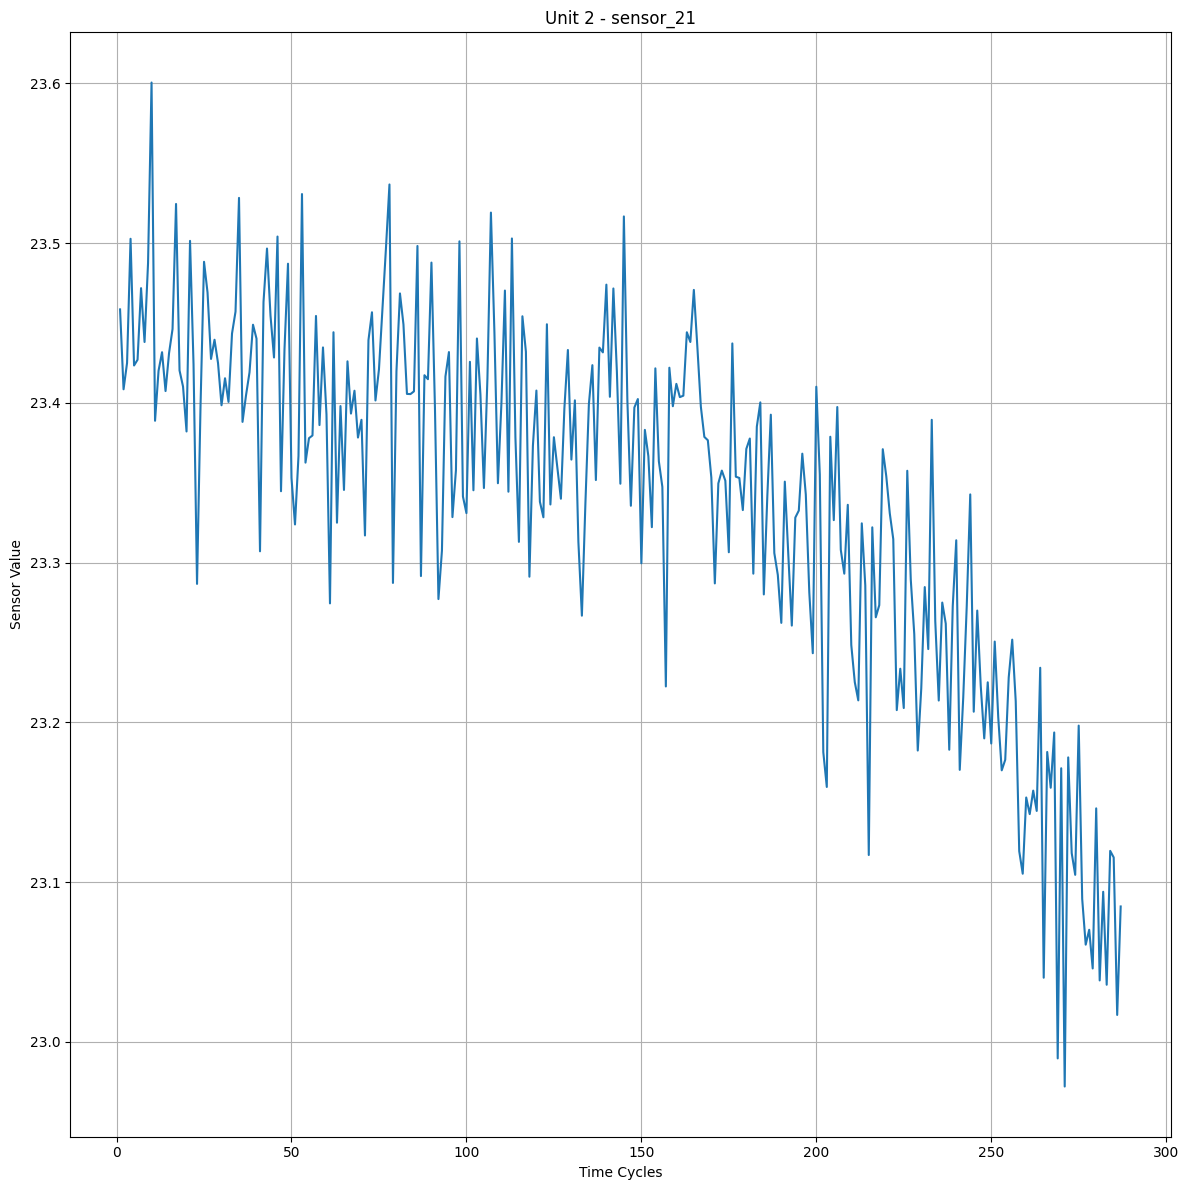


Plotting Unit 3...


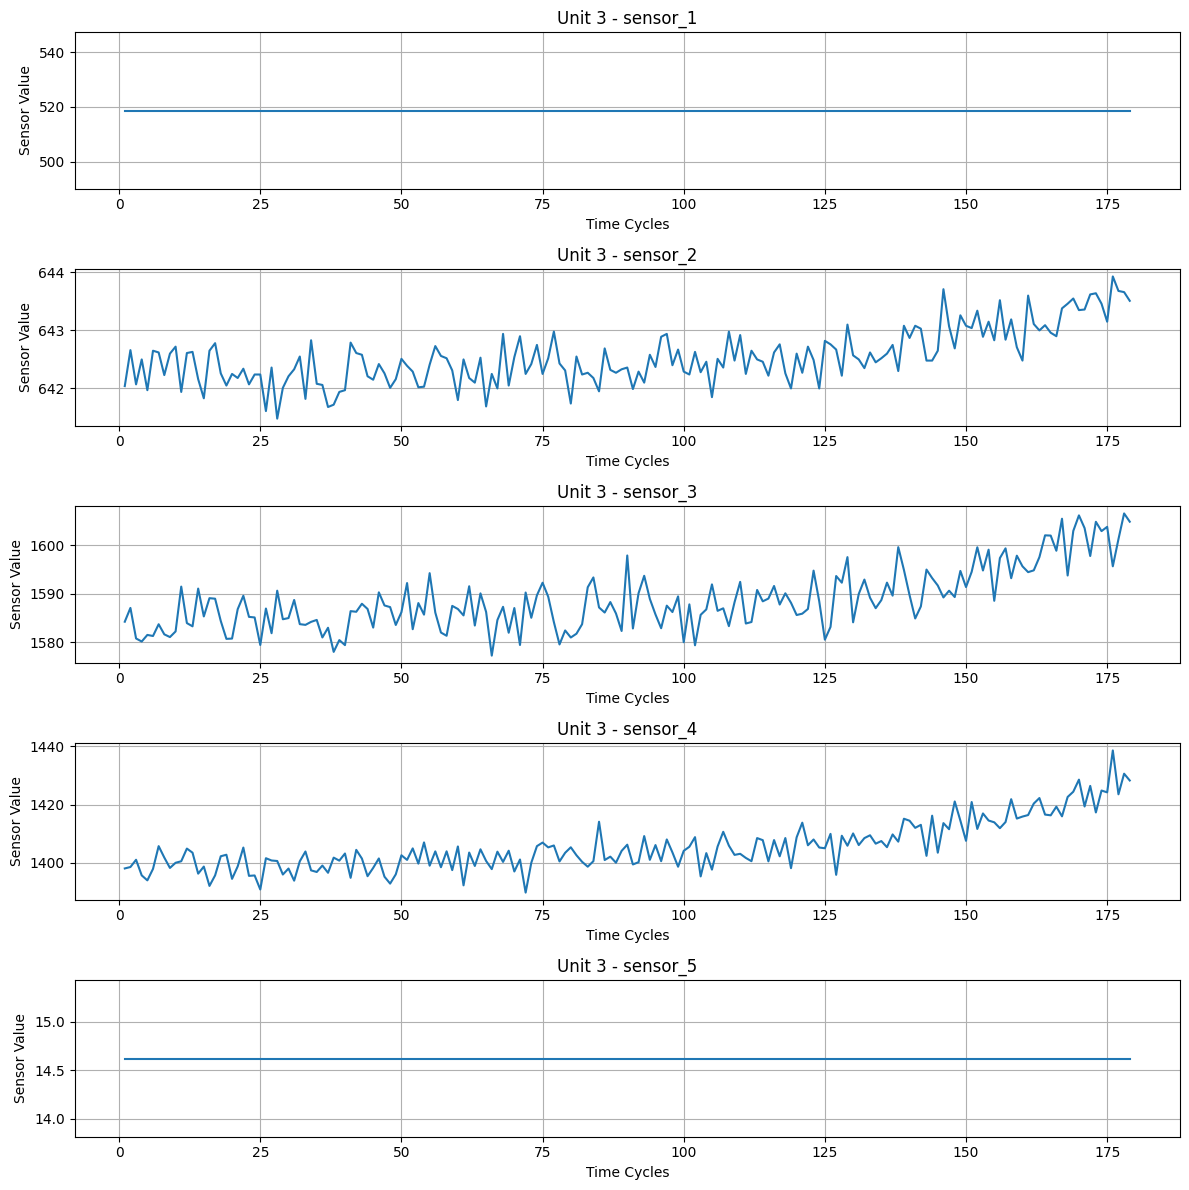

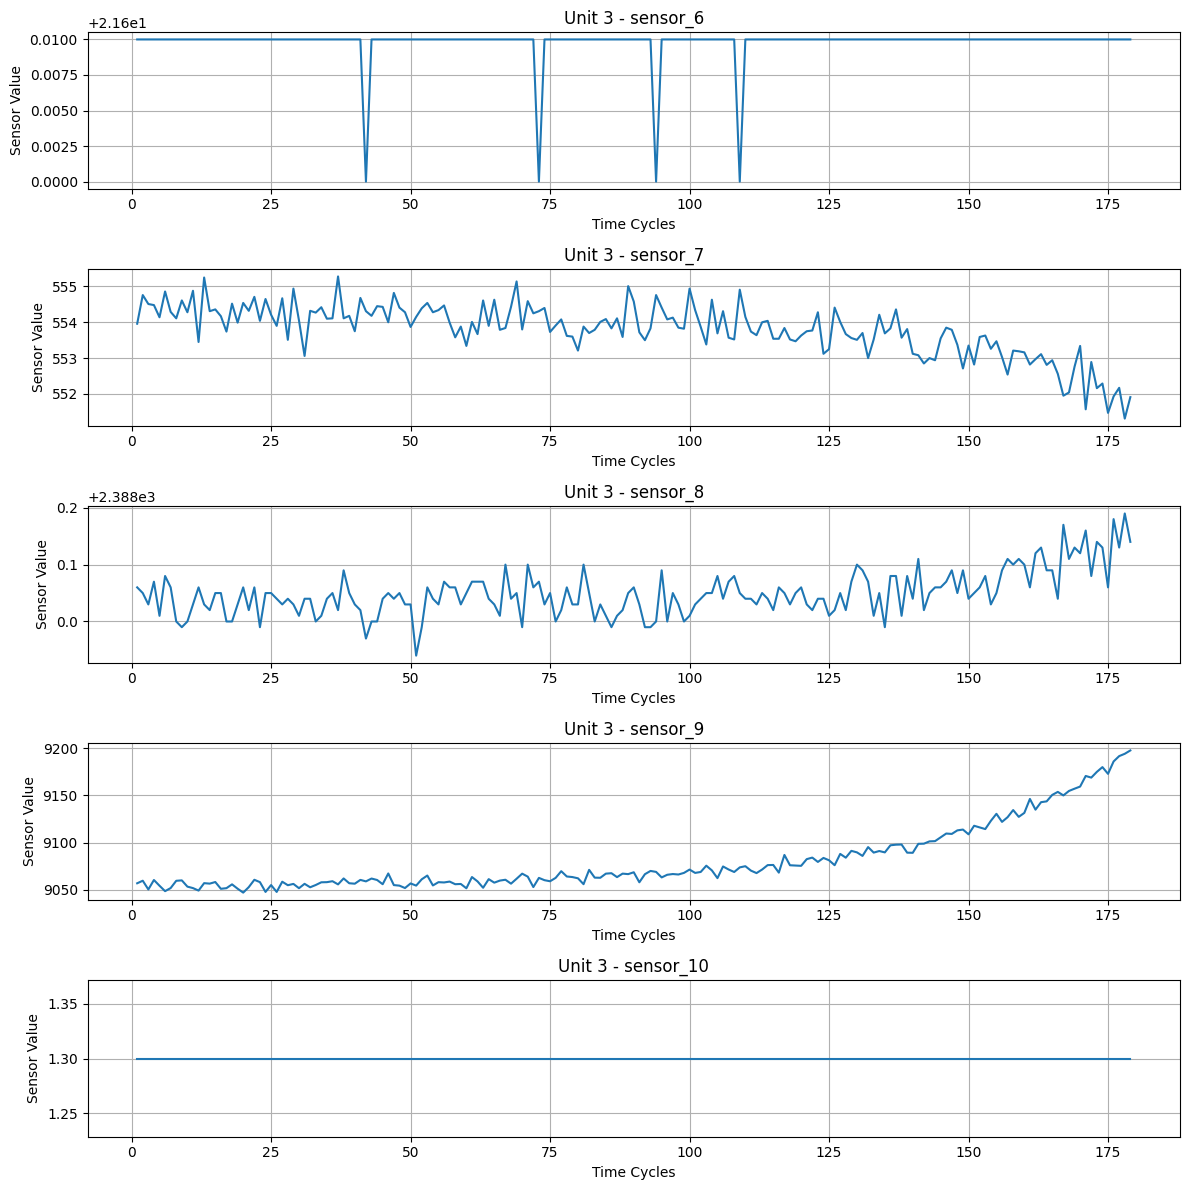

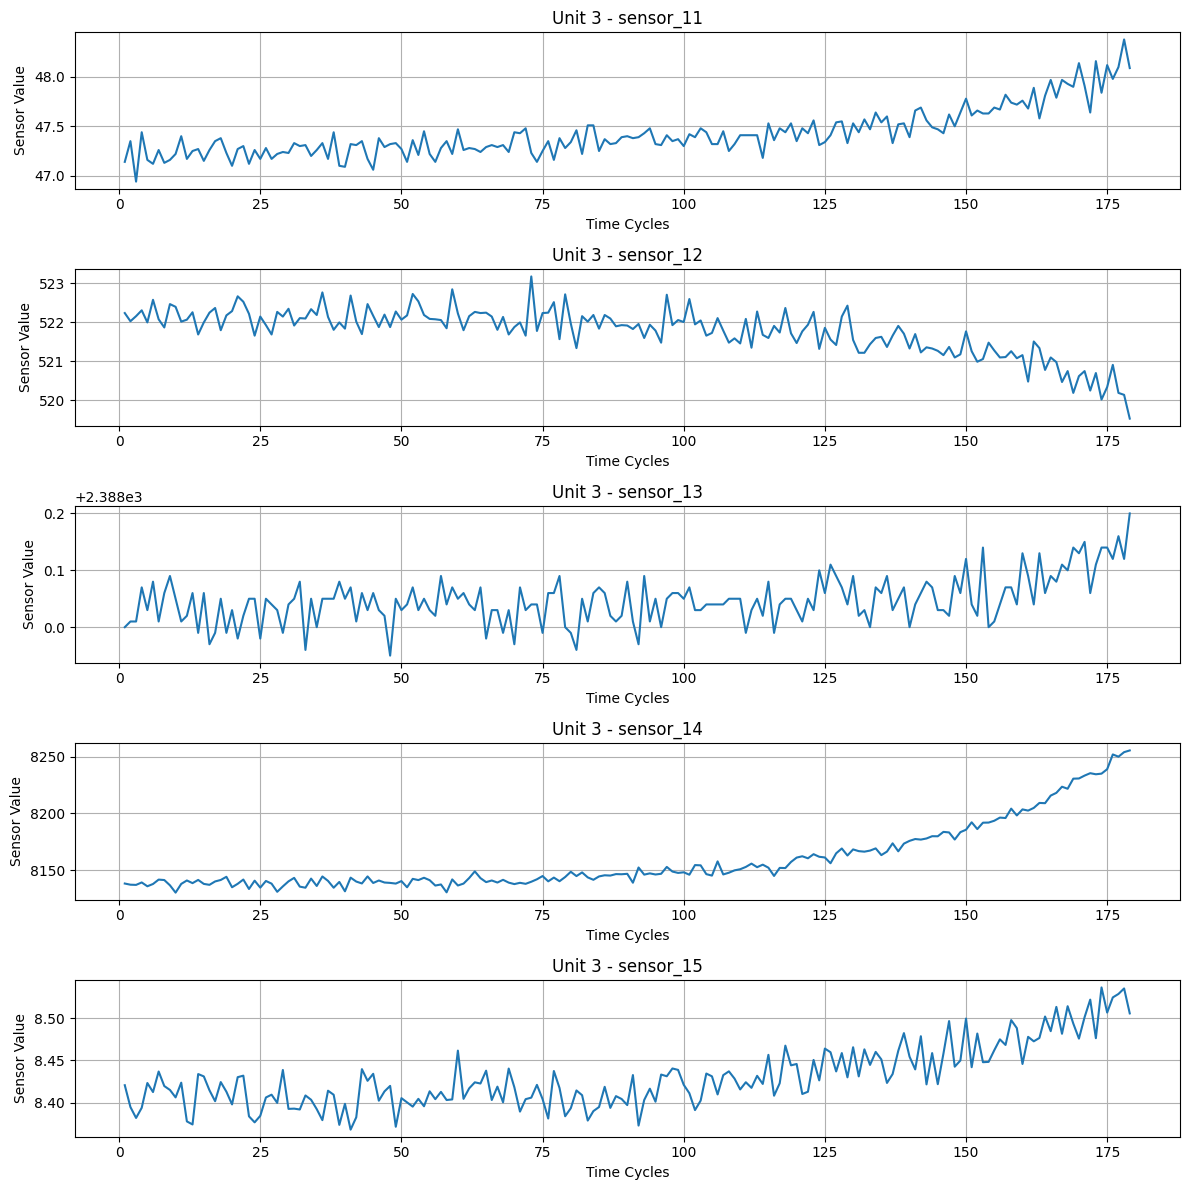

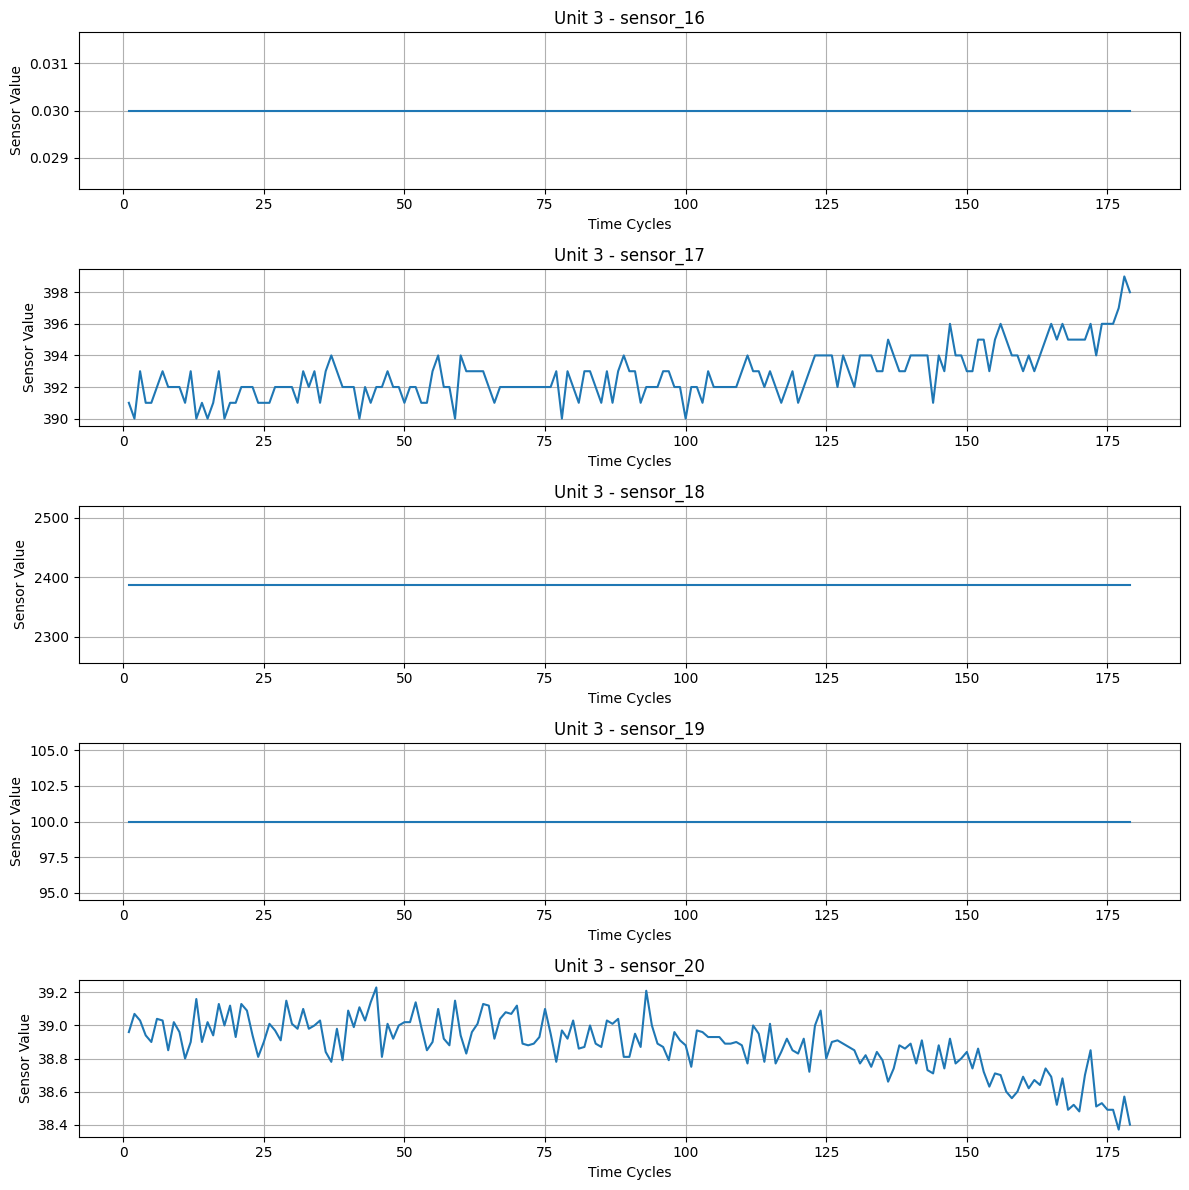

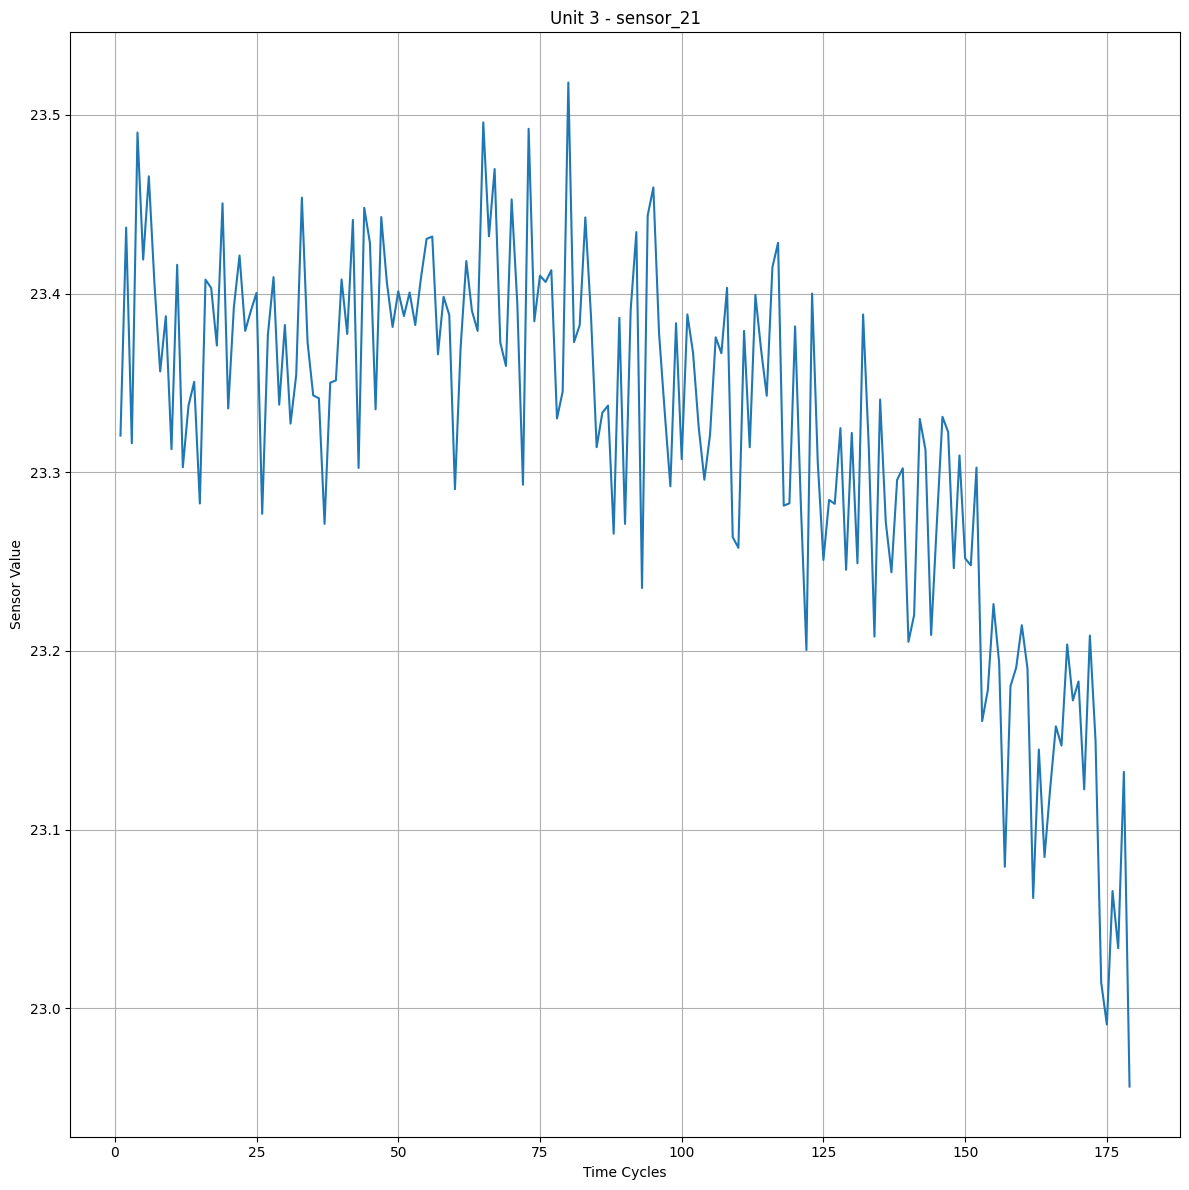

In [8]:
for unit in units:

    # Ambil data untuk unit tertentu
    unit_data = train[train["unit_number"] == unit]

    print(f"\nPlotting Unit {unit}...")

    # Bagi sensor menjadi kelompok 5
    for start in range(0, len(sensor_cols), 5):

        sensors = sensor_cols[start:start + 5]

        # Buat subplot
        fig, axes = plt.subplots(
            nrows=len(sensors),
            ncols=1,
            figsize=(12, 12)
        )

        # Kalau hanya ada satu subplot,
        # ubah menjadi list agar bisa di-loop
        if len(sensors) == 1:
            axes = [axes]

        # Plot setiap sensor
        for ax, sensor in zip(axes, sensors):

            ax.plot(
                unit_data["time_cycles"],
                unit_data[sensor]
            )

            ax.set_title(f"Unit {unit} - {sensor}")
            ax.set_xlabel("Time Cycles")
            ax.set_ylabel("Sensor Value")

            ax.grid(True)

        plt.tight_layout()
        plt.show()

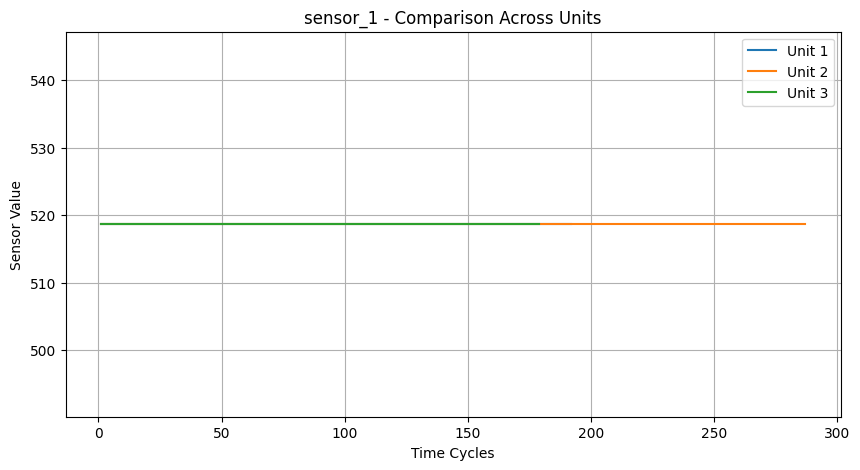

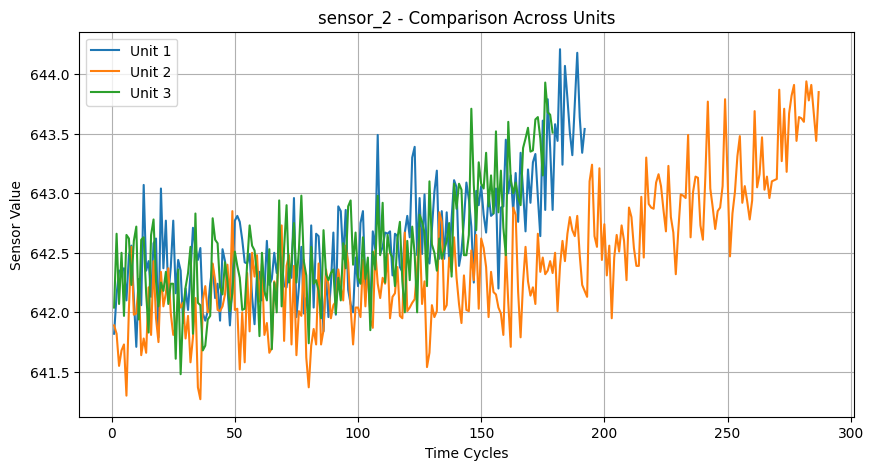

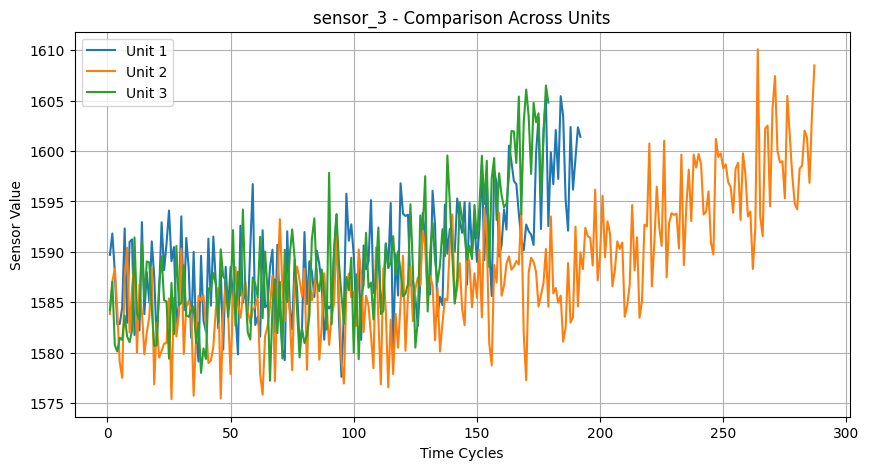

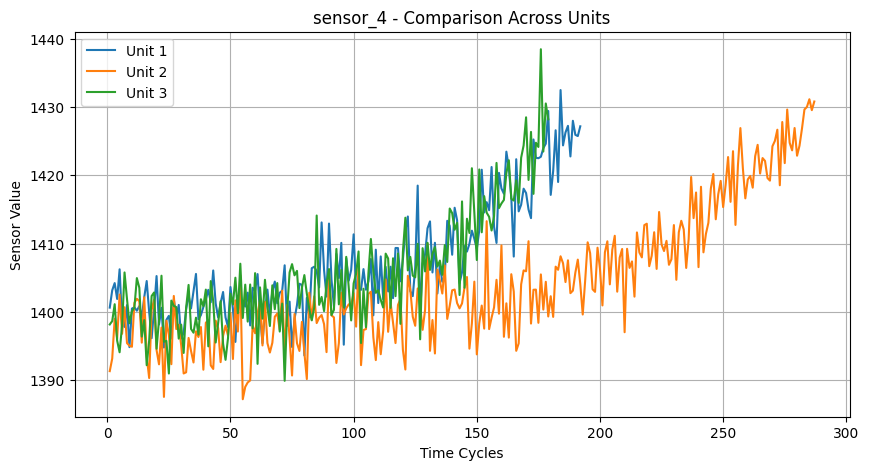

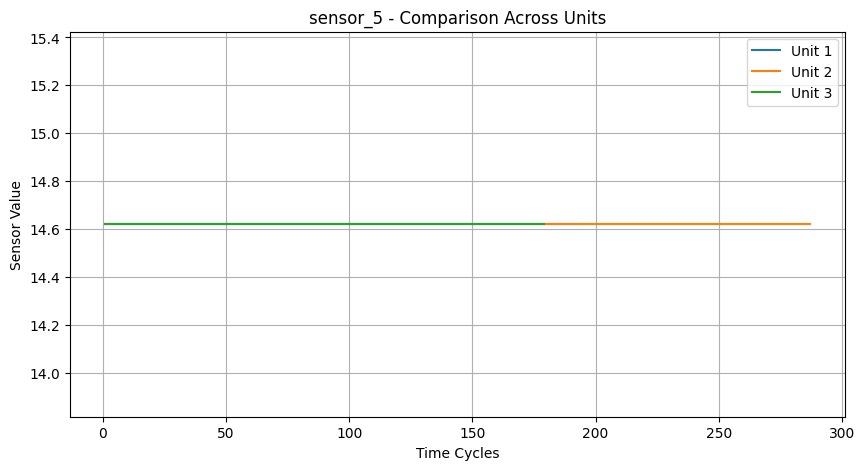

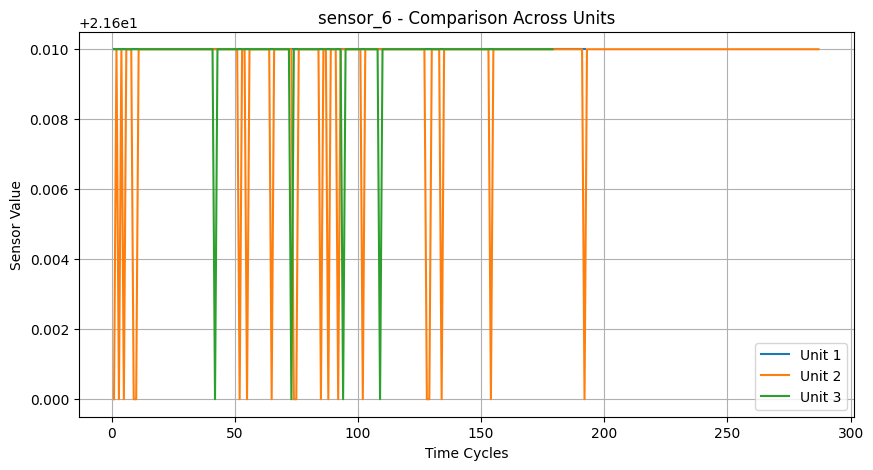

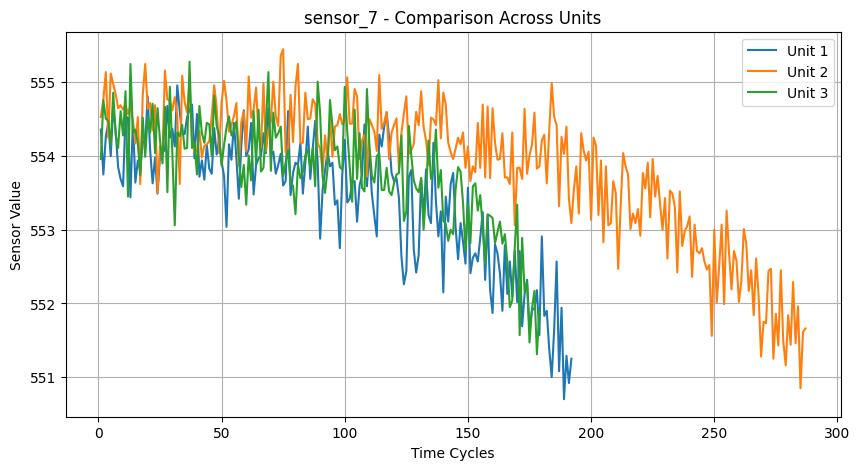

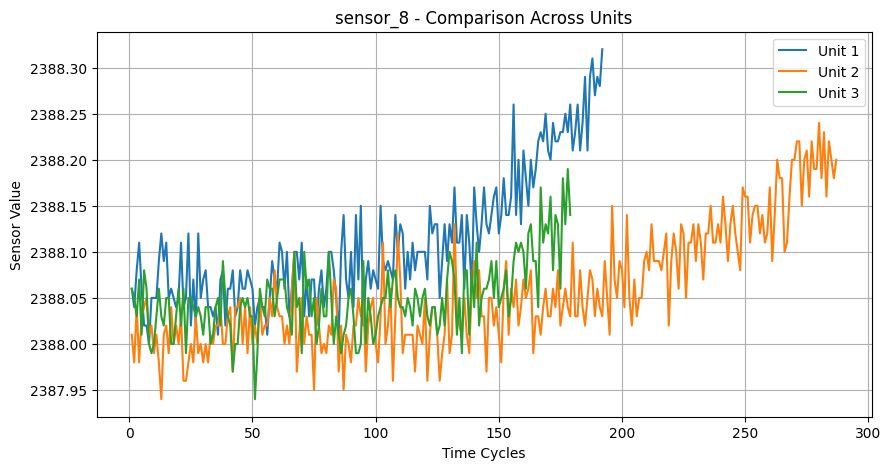

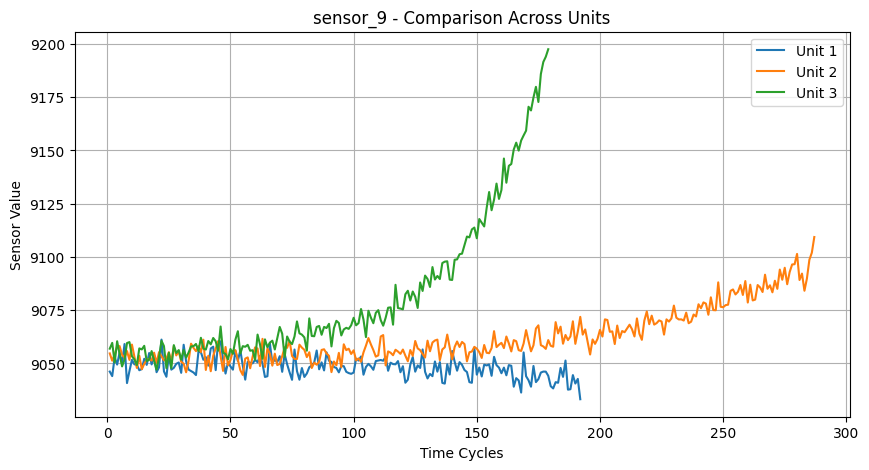

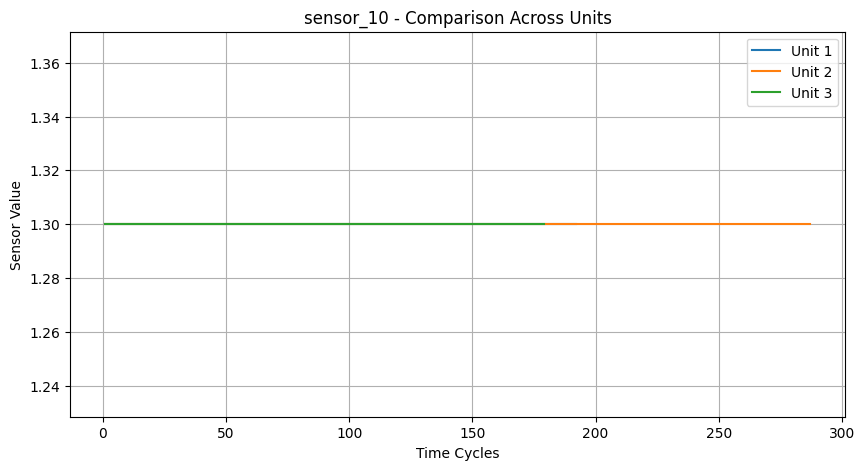

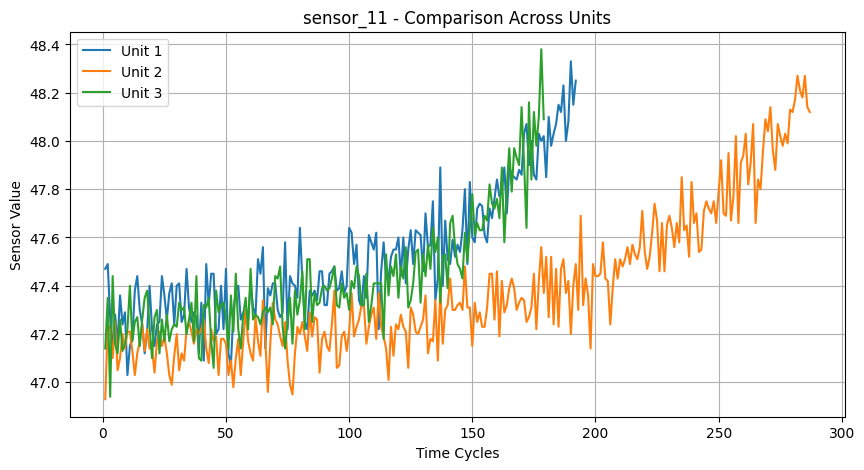

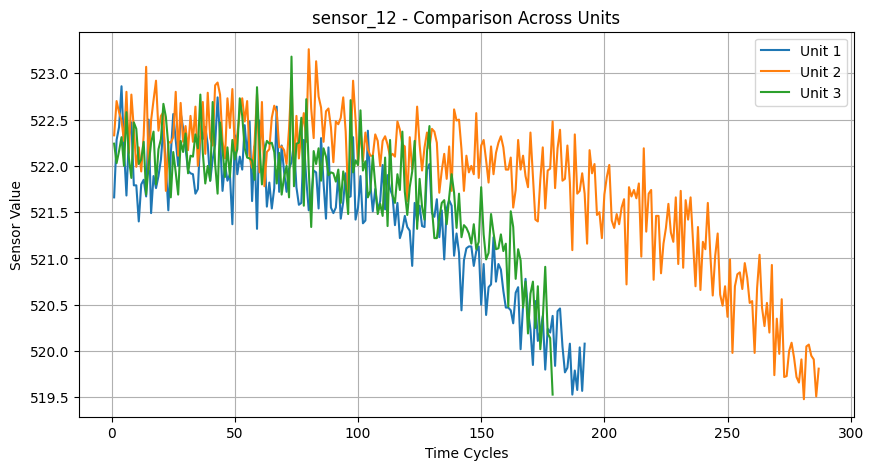

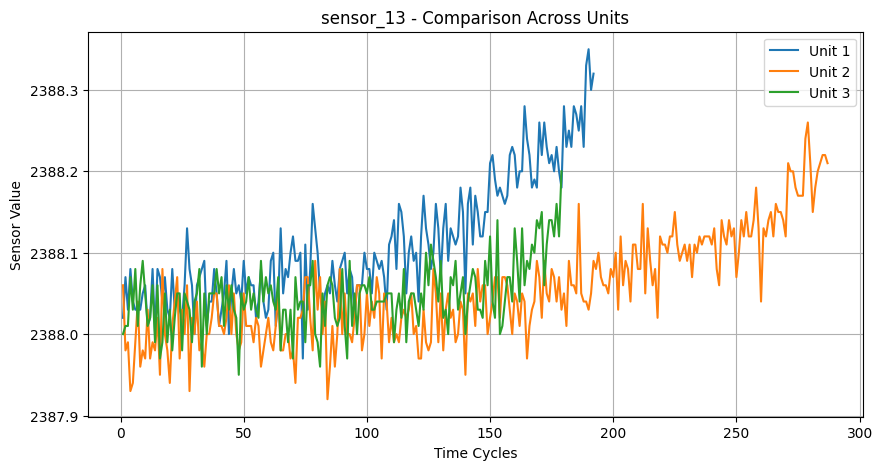

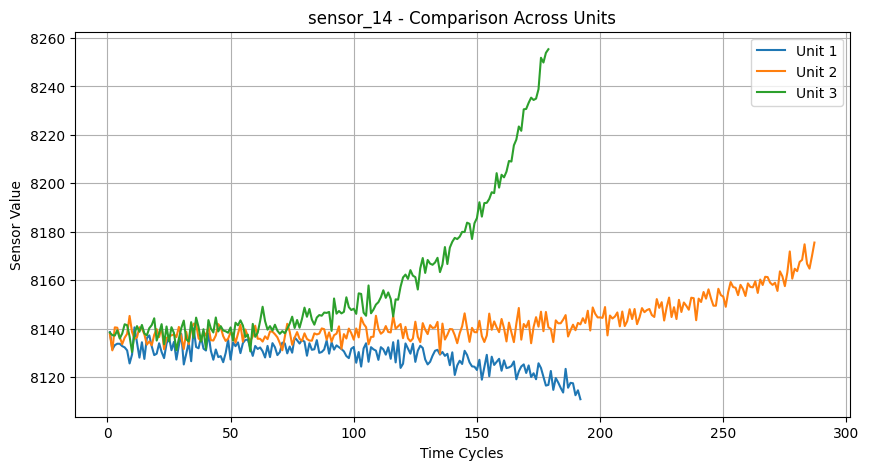

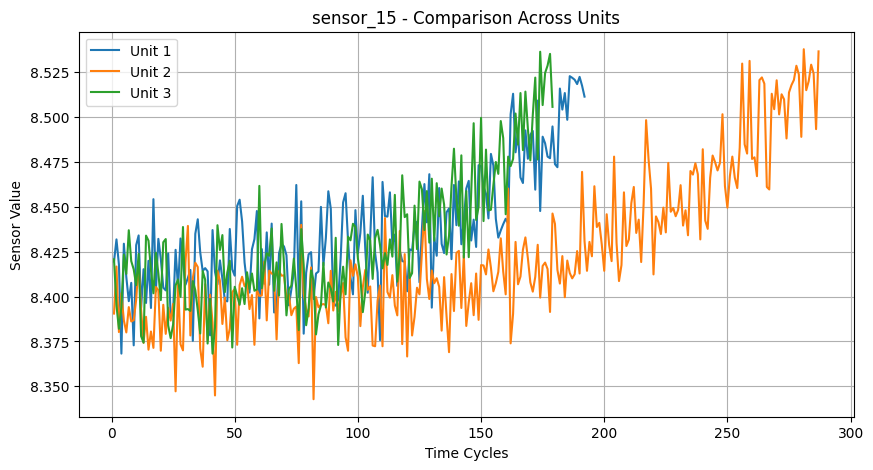

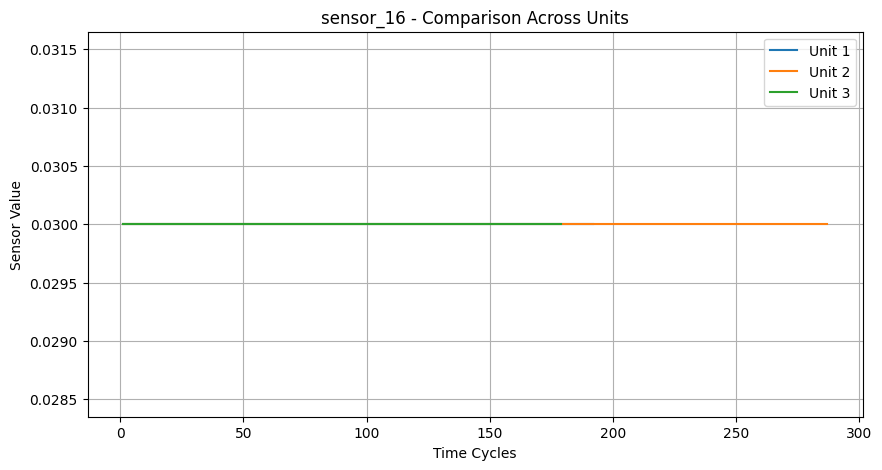

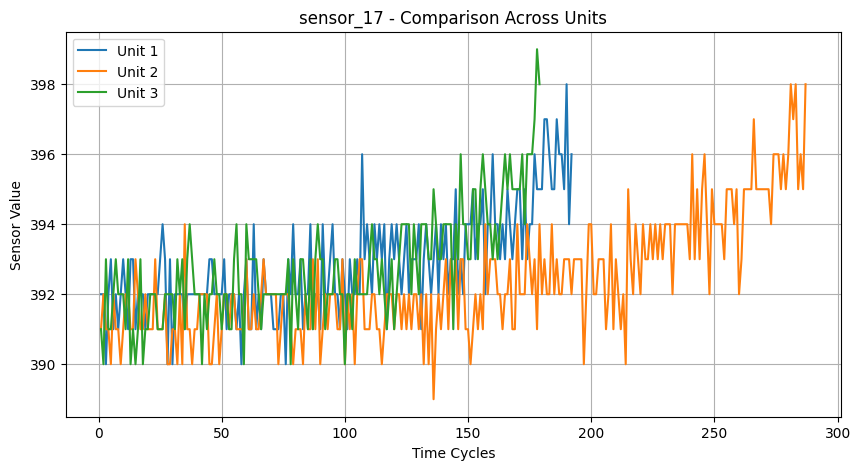

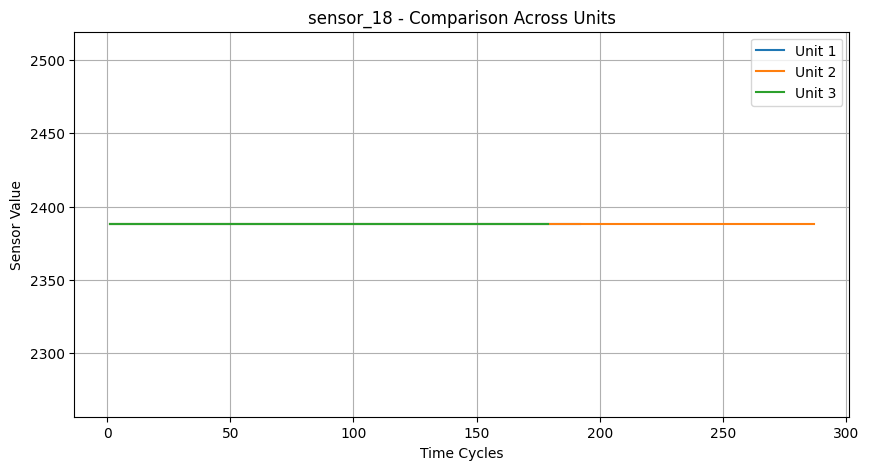

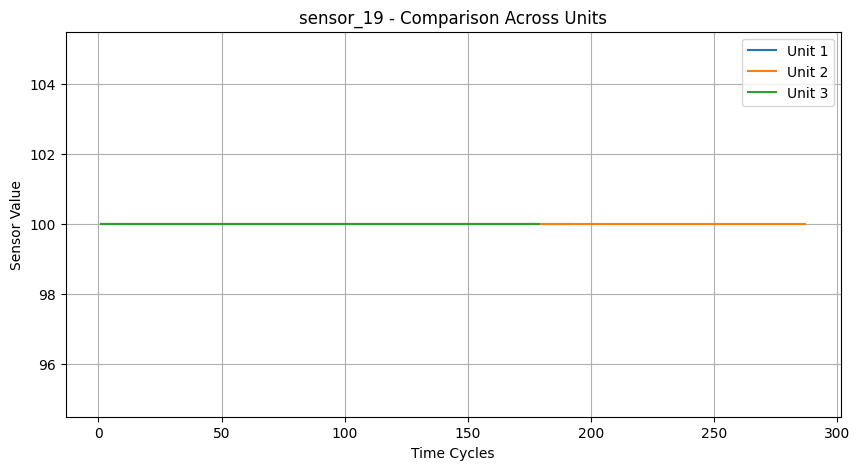

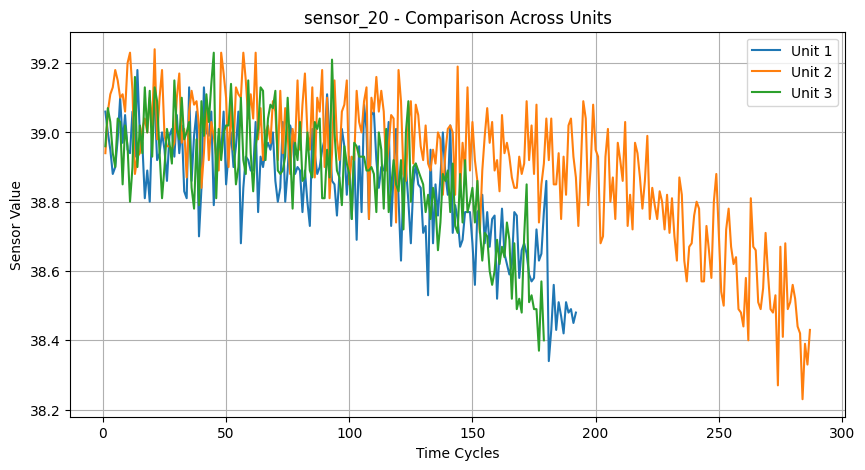

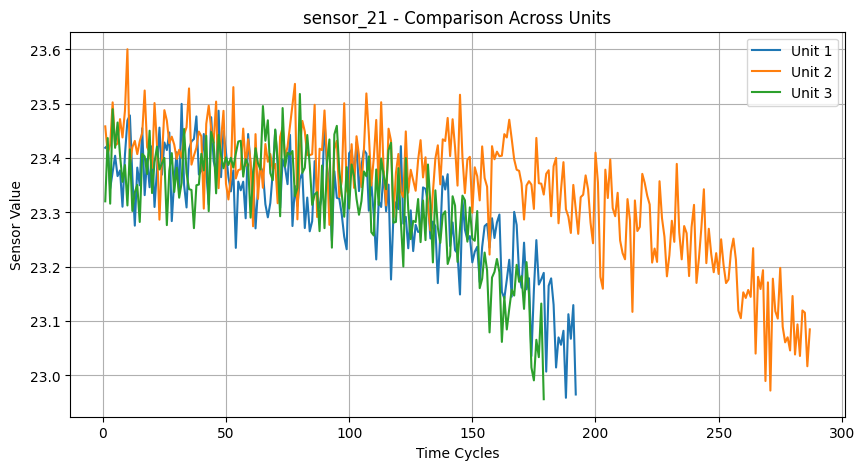

In [9]:
for sensor in sensor_cols:

    plt.figure(figsize=(10, 5))

    for unit in units:

        unit_data = train[train["unit_number"] == unit]

        plt.plot(
            unit_data["time_cycles"],
            unit_data[sensor],
            label=f"Unit {unit}"
        )

    plt.title(f"{sensor} - Comparison Across Units")
    plt.xlabel("Time Cycles")
    plt.ylabel("Sensor Value")
    plt.legend()
    plt.grid(True)

    plt.show()

## 4. Calculate RUL

In [10]:
train["max_cycle"] = (
    train.groupby("unit_number")["time_cycles"]
         .transform("max")
)

train["RUL"] = (
    train["max_cycle"] - train["time_cycles"]
)

print("\nData setelah menghitung RUL:")
print(
    train[
        ["unit_number", "time_cycles", "max_cycle", "RUL"]
    ].head(10)
)


Data setelah menghitung RUL:
   unit_number  time_cycles  max_cycle  RUL
0            1            1        192  191
1            1            2        192  190
2            1            3        192  189
3            1            4        192  188
4            1            5        192  187
5            1            6        192  186
6            1            7        192  185
7            1            8        192  184
8            1            9        192  183
9            1           10        192  182


In [11]:
print("\n====================================")
print("RUL CHECK PER UNIT")
print("====================================")

check = (
    train
    .groupby("unit_number")
    .agg(
        max_cycle=("time_cycles", "max"),
        max_RUL=("RUL", "max"),
        min_RUL=("RUL", "min")
    )
    .head(10)
)

print(check)


RUL CHECK PER UNIT
             max_cycle  max_RUL  min_RUL
unit_number                             
1                  192      191        0
2                  287      286        0
3                  179      178        0
4                  189      188        0
5                  269      268        0
6                  188      187        0
7                  259      258        0
8                  150      149        0
9                  201      200        0
10                 222      221        0


## 5. Creating Rolling Window for train

In [13]:
import pandas as pd

selected_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
]

# Sort data
train = train.sort_values(
    ["unit_number", "time_cycles"]
).reset_index(drop=True)


# Rolling mean
window = 5

for sensor in selected_sensors:

    # Rolling Mean

    train[f"{sensor}_roll_mean"] = (
        train.groupby("unit_number")[sensor]
             .transform(
                 lambda x: x.rolling(
                     window=window
                 ).mean()
             )
    )

    
    # Rolling Rate of Change

    train[f"{sensor}_roc"] = (
        train.groupby("unit_number")[f"{sensor}_roll_mean"]
             .diff()
    )


# result

print("\nData setelah rolling features:")

print(
    train[
        [
            "unit_number",
            "time_cycles",
            "sensor_2",
            "sensor_2_roll_mean",
            "sensor_2_roc",
            "RUL"
        ]
    ].head(10)
)


# check rolling column

rolling_columns = []

for sensor in selected_sensors:

    rolling_columns.append(
        f"{sensor}_roll_mean"
    )

    rolling_columns.append(
        f"{sensor}_roc"
    )


print("\nJumlah rolling features:",
      len(rolling_columns))

print("\nRolling features:")
print(rolling_columns)


# check null

print("\nJumlah NaN pada rolling features:")

print(
    train[rolling_columns]
    .isna()
    .sum()
)


# check null per unit

print("\nNaN pada beberapa unit:")

nan_check = (
    train
    .groupby("unit_number")[rolling_columns]
    .apply(lambda x: x.isna().sum().sum())
)

print(nan_check.head(10))

# drop null row

train = train.dropna(
    subset=rolling_columns
).reset_index(drop=True)


# print final result

print("\n====================================")
print("FINAL CHECK")
print("====================================")

print("Shape setelah drop NaN:",
      train.shape)

print("\nJumlah NaN:")
print(
    train[rolling_columns]
    .isna()
    .sum()
    .sum()
)

print("\nContoh data:")
print(
    train[
        [
            "unit_number",
            "time_cycles",
            "sensor_2_roll_mean",
            "sensor_2_roc",
            "RUL"
        ]
    ].head(10)
)


Data setelah rolling features:
   unit_number  time_cycles  sensor_2  sensor_2_roll_mean  sensor_2_roc  RUL
0            1            1    641.82                 NaN           NaN  191
1            1            2    642.15                 NaN           NaN  190
2            1            3    642.35                 NaN           NaN  189
3            1            4    642.35                 NaN           NaN  188
4            1            5    642.37             642.208           NaN  187
5            1            6    642.10             642.264         0.056  186
6            1            7    642.48             642.330         0.066  185
7            1            8    642.56             642.372         0.042  184
8            1            9    642.12             642.326        -0.046  183
9            1           10    641.71             642.194        -0.132  182

Jumlah rolling features: 28

Rolling features:
['sensor_2_roll_mean', 'sensor_2_roc', 'sensor_3_roll_mean', 'sensor_3_ro

## 6. Creating Rolling Window for test

In [16]:
import pandas as pd

selected_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
]

# Sort data
test = test.sort_values(
    ["unit_number", "time_cycles"]
).reset_index(drop=True)


# Rolling mean
window = 5

for sensor in selected_sensors:

    # Rolling Mean

    test[f"{sensor}_roll_mean"] = (
        test.groupby("unit_number")[sensor]
             .transform(
                 lambda x: x.rolling(
                     window=window
                 ).mean()
             )
    )

    
    # Rolling Rate of Change

    test[f"{sensor}_roc"] = (
        test.groupby("unit_number")[f"{sensor}_roll_mean"]
             .diff()
    )


# check rolling column

rolling_columns = []

for sensor in selected_sensors:

    rolling_columns.append(
        f"{sensor}_roll_mean"
    )

    rolling_columns.append(
        f"{sensor}_roc"
    )


# result check
print("Test shape:", test.shape)

print("\nRolling features:")
print(rolling_columns)

print("\nJumlah rolling features:",
      len(rolling_columns))


# check null

print("\nJumlah NaN pada rolling features:")

print(
    test[rolling_columns]
    .isna()
    .sum()
)


# check null per unit

print("\nNaN pada beberapa unit:")

nan_check = (
    test
    .groupby("unit_number")[rolling_columns]
    .apply(lambda x: x.isna().sum().sum())
)

print(nan_check.head(10))

# drop null row

test = test.dropna(
    subset=rolling_columns
).reset_index(drop=True)


# print final result

print("\n====================================")
print("FINAL TEST CHECK")
print("====================================")

print("Test shape after drop NaN:",
      test.shape)

print("\nTotal NaN:",
      test[rolling_columns].isna().sum().sum())

print("\nFirst rows:")
print(
    test[
        [
            "unit_number",
            "time_cycles",
            "sensor_2_roll_mean",
            "sensor_2_roc"
        ]
    ].head(10)
)

Test shape: (13096, 54)

Rolling features:
['sensor_2_roll_mean', 'sensor_2_roc', 'sensor_3_roll_mean', 'sensor_3_roc', 'sensor_4_roll_mean', 'sensor_4_roc', 'sensor_7_roll_mean', 'sensor_7_roc', 'sensor_8_roll_mean', 'sensor_8_roc', 'sensor_9_roll_mean', 'sensor_9_roc', 'sensor_11_roll_mean', 'sensor_11_roc', 'sensor_12_roll_mean', 'sensor_12_roc', 'sensor_13_roll_mean', 'sensor_13_roc', 'sensor_14_roll_mean', 'sensor_14_roc', 'sensor_15_roll_mean', 'sensor_15_roc', 'sensor_17_roll_mean', 'sensor_17_roc', 'sensor_20_roll_mean', 'sensor_20_roc', 'sensor_21_roll_mean', 'sensor_21_roc']

Jumlah rolling features: 28

Jumlah NaN pada rolling features:
sensor_2_roll_mean     400
sensor_2_roc           500
sensor_3_roll_mean     400
sensor_3_roc           500
sensor_4_roll_mean     400
sensor_4_roc           500
sensor_7_roll_mean     400
sensor_7_roc           500
sensor_8_roll_mean     400
sensor_8_roc           500
sensor_9_roll_mean     400
sensor_9_roc           500
sensor_11_roll_mean 

## 7. Representatif row per unit from test set

In [17]:
# --------------------------------------------
# 1. SORT BERDASARKAN UNIT DAN TIME CYCLE
# --------------------------------------------

test = test.sort_values(
    ["unit_number", "time_cycles"]
).reset_index(drop=True)


# --------------------------------------------
# 2. AMBIL BARIS DENGAN TIME_CYCLES
#    MAKSIMUM UNTUK SETIAP UNIT
# --------------------------------------------

test_last = (
    test
    .groupby("unit_number")
    .tail(1)
    .reset_index(drop=True)
)


# --------------------------------------------
# 3. CEK HASIL
# --------------------------------------------

print("Shape test_last:")
print(test_last.shape)


print("\nJumlah unit:")
print(test_last["unit_number"].nunique())


print("\nJumlah baris:")
print(len(test_last))


# --------------------------------------------
# 4. VALIDASI HARUS 100 BARIS
# --------------------------------------------

if len(test_last) == 100:
    print("\n✓ Test set memiliki tepat 100 baris")
else:
    print(
        f"\n✗ Test set memiliki {len(test_last)} baris"
    )


# --------------------------------------------
# 5. CEK SETIAP UNIT HANYA MUNCUL SEKALI
# --------------------------------------------

unit_counts = (
    test_last["unit_number"]
    .value_counts()
)

if unit_counts.max() == 1:
    print("✓ Setiap unit hanya memiliki 1 baris")
else:
    print("✗ Ada unit yang muncul lebih dari sekali")


# --------------------------------------------
# 6. Check Final Result
# --------------------------------------------

print("\n====================================")
print("FINAL REPRESENTATIVE TEST DATA")
print("====================================")

print(
    test_last[
        [
            "unit_number",
            "time_cycles",
            "sensor_2_roll_mean",
            "sensor_2_roc"
        ]
    ].head(10)
)

Shape test_last:
(100, 54)

Jumlah unit:
100

Jumlah baris:
100

✓ Test set memiliki tepat 100 baris
✓ Setiap unit hanya memiliki 1 baris

FINAL REPRESENTATIVE TEST DATA
   unit_number  time_cycles  sensor_2_roll_mean  sensor_2_roc
0            1           31             642.266         0.020
1            2           49             642.672        -0.044
2            3          126             642.874        -0.034
3            4          106             642.786        -0.080
4            5           98             642.702        -0.120
5            6          105             642.586         0.050
6            7          160             642.216        -0.038
7            8          166             642.890        -0.056
8            9           55             642.550        -0.090
9           10          192             642.798         0.092


## 8. Training Model

In [19]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [20]:
# ============================================================
# 1. FEATURE LIST
# ============================================================

# Gunakan HANYA fitur hasil rolling dari Tahap D
# Bukan sensor mentah

rolling_columns = []

for sensor in selected_sensors:

    rolling_columns.append(
        f"{sensor}_roll_mean"
    )

    rolling_columns.append(
        f"{sensor}_roc"
    )


print("====================================")
print("FEATURE LIST")
print("====================================")

print("Jumlah features:", len(rolling_columns))

print("\nFeatures:")
print(rolling_columns)


# ============================================================
# 2. SIAPKAN X_train DAN y_train
# ============================================================

X_train = train[rolling_columns]

y_train = train["RUL"]


print("\n====================================")
print("TRAINING DATA")
print("====================================")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nJumlah NaN X_train:")
print(X_train.isna().sum().sum())

print("\nJumlah NaN y_train:")
print(y_train.isna().sum())


# ============================================================
# 3. SIAPKAN TEST DATA
# ============================================================

test_last = (
    test_last
    .sort_values("unit_number")
    .reset_index(drop=True)
)


# Ambil unit_number untuk validasi
test_units = test_last["unit_number"].tolist()


print("\n====================================")
print("TEST UNIT CHECK")
print("====================================")

print("Jumlah test units:", len(test_units))

print("\n10 unit pertama:")
print(test_units[:10])

print("\n10 unit terakhir:")
print(test_units[-10:])


# ============================================================
# 4. VALIDASI UNIT NUMBER
# ============================================================

expected_units = list(range(1, 101))


if test_units == expected_units:

    print("\n✓ Unit test berurutan dari 1 sampai 100")

else:

    print("\n✗ URUTAN UNIT TEST TIDAK SESUAI!")

    print("\nExpected:")
    print(expected_units)

    print("\nActual:")
    print(test_units)

    raise ValueError(
        "Urutan unit_number tidak sesuai 1-100."
    )


# ============================================================
# 5. LOAD TRUE RUL
# ============================================================

print("\n====================================")
print("TRUE RUL")
print("====================================")

print("Shape rul_true:", rul_true.shape)

print("\nFirst 10 true RUL:")
print(rul_true.head(10))


# ============================================================
# 6. VALIDASI JUMLAH RUL
# ============================================================

if len(rul_true) == len(test_last):

    print(
        f"\n✓ Jumlah RUL ({len(rul_true)}) "
        f"cocok dengan jumlah test unit ({len(test_last)})"
    )

else:

    raise ValueError(
        f"Jumlah RUL ({len(rul_true)}) "
        f"tidak sama dengan jumlah test unit "
        f"({len(test_last)})"
    )


# ============================================================
# 7. BUAT MAPPING UNIT_NUMBER → TRUE RUL
# ============================================================

rul_true["unit_number"] = range(
    1,
    len(rul_true) + 1
)


print("\n====================================")
print("RUL MAPPING")
print("====================================")

print(rul_true.head(10))


# ============================================================
# 8. MATCH TRUE RUL DENGAN TEST UNIT
# ============================================================

# Merge berdasarkan unit_number
# BUKAN berdasarkan posisi baris secara langsung

test_evaluation = test_last.merge(
    rul_true,
    on="unit_number",
    how="left",
    validate="one_to_one"
)


# ============================================================
# 9. VALIDASI HASIL MATCHING
# ============================================================

print("\n====================================")
print("MATCHING CHECK")
print("====================================")

print(
    test_evaluation[
        ["unit_number", "time_cycles", "RUL"]
    ].head(10)
)

print("\nJumlah missing RUL:")
print(
    test_evaluation["RUL"].isna().sum()
)


if test_evaluation["RUL"].isna().sum() == 0:

    print("\n✓ Semua test unit memiliki true RUL")

else:

    raise ValueError(
        "Ada test unit yang tidak memiliki true RUL."
    )

FEATURE LIST
Jumlah features: 28

Features:
['sensor_2_roll_mean', 'sensor_2_roc', 'sensor_3_roll_mean', 'sensor_3_roc', 'sensor_4_roll_mean', 'sensor_4_roc', 'sensor_7_roll_mean', 'sensor_7_roc', 'sensor_8_roll_mean', 'sensor_8_roc', 'sensor_9_roll_mean', 'sensor_9_roc', 'sensor_11_roll_mean', 'sensor_11_roc', 'sensor_12_roll_mean', 'sensor_12_roc', 'sensor_13_roll_mean', 'sensor_13_roc', 'sensor_14_roll_mean', 'sensor_14_roc', 'sensor_15_roll_mean', 'sensor_15_roc', 'sensor_17_roll_mean', 'sensor_17_roc', 'sensor_20_roll_mean', 'sensor_20_roc', 'sensor_21_roll_mean', 'sensor_21_roc']

TRAINING DATA
X_train shape: (20131, 28)
y_train shape: (20131,)

Jumlah NaN X_train:
0

Jumlah NaN y_train:
0

TEST UNIT CHECK
Jumlah test units: 100

10 unit pertama:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

10 unit terakhir:
[91, 92, 93, 94, 95, 96, 97, 98, 99, 100]

✓ Unit test berurutan dari 1 sampai 100

TRUE RUL
Shape rul_true: (100, 1)

First 10 true RUL:
   RUL
0  112
1   98
2   69
3   82
4   91
5   93

In [21]:
# ============================================================
# 10. SUSUN X_test DAN y_test
# ============================================================

X_test = test_evaluation[
    rolling_columns
]

y_test = test_evaluation[
    "RUL"
]


print("\n====================================")
print("FINAL DATASET")
print("====================================")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ============================================================
# 11. FINAL NaN CHECK
# ============================================================

print("\n====================================")
print("FINAL NaN CHECK")
print("====================================")

print("X_train NaN:", X_train.isna().sum().sum())
print("y_train NaN:", y_train.isna().sum())

print("X_test NaN :", X_test.isna().sum().sum())
print("y_test NaN :", y_test.isna().sum())


if X_train.isna().sum().sum() > 0:
    raise ValueError("X_train masih memiliki NaN.")

if X_test.isna().sum().sum() > 0:
    raise ValueError("X_test masih memiliki NaN.")

if y_train.isna().sum() > 0:
    raise ValueError("y_train masih memiliki NaN.")

if y_test.isna().sum() > 0:
    raise ValueError("y_test masih memiliki NaN.")


print("\n✓ Semua data siap untuk training!")


FINAL DATASET
X_train: (20131, 28)
y_train: (20131,)
X_test : (100, 28)
y_test : (100,)

FINAL NaN CHECK
X_train NaN: 0
y_train NaN: 0
X_test NaN : 0
y_test NaN : 0

✓ Semua data siap untuk training!


In [22]:
# ============================================================
# 12. MODEL 1: LINEAR REGRESSION
# ============================================================

print("\n====================================")
print("LINEAR REGRESSION")
print("====================================")

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

print("✓ Linear Regression selesai training")

print("\nContoh prediction:")
print(linear_pred[:10])


LINEAR REGRESSION
✓ Linear Regression selesai training

Contoh prediction:
[164.52878456 129.35915309  88.13690124  96.42099601 109.49398701
 125.53947485 136.29149152 101.68264493 126.80103557 120.22070287]


In [23]:
# ============================================================
# 13. MODEL 2: RANDOM FOREST REGRESSOR
# ============================================================

print("\n====================================")
print("RANDOM FOREST REGRESSOR")
print("====================================")

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

print("✓ Random Forest selesai training")

print("\nContoh prediction:")
print(rf_pred[:10])


RANDOM FOREST REGRESSOR
✓ Random Forest selesai training

Contoh prediction:
[167.8  144.48  43.94 119.11 131.2  167.86 106.82 125.6  146.01 130.51]


In [24]:
# ============================================================
# 14. GABUNGKAN HASIL PREDIKSI
# ============================================================

results = pd.DataFrame({
    "unit_number": test_evaluation["unit_number"],
    "true_RUL": y_test,
    "LinearRegression_RUL": linear_pred,
    "RandomForest_RUL": rf_pred
})


print("\n====================================")
print("PREDICTION RESULTS")
print("====================================")

print(
    results.head(10)
)


PREDICTION RESULTS
   unit_number  true_RUL  LinearRegression_RUL  RandomForest_RUL
0            1       112            164.528785            167.80
1            2        98            129.359153            144.48
2            3        69             88.136901             43.94
3            4        82             96.420996            119.11
4            5        91            109.493987            131.20
5            6        93            125.539475            167.86
6            7        91            136.291492            106.82
7            8        95            101.682645            125.60
8            9       111            126.801036            146.01
9           10        96            120.220703            130.51


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ============================================
# EVALUASI MODEL
# ============================================

# Linear Regression
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)


# Random Forest
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)


# ============================================
# TAMPILKAN HASIL
# ============================================

print("====================================")
print("MODEL EVALUATION")
print("====================================")

print(
    f"\nLinear Regression"
    f"\nMAE  : {linear_mae:.2f}"
    f"\nRMSE : {linear_rmse:.2f}"
)

print(
    f"\nRandom Forest Regressor"
    f"\nMAE  : {rf_mae:.2f}"
    f"\nRMSE : {rf_rmse:.2f}"
)

MODEL EVALUATION

Linear Regression
MAE  : 26.83
RMSE : 33.00

Random Forest Regressor
MAE  : 24.22
RMSE : 36.11


## 9. Finding Unit with the highest error

In [26]:
import pandas as pd


# ------------------------------------------------------------
# 1. Hitung absolute error
# ------------------------------------------------------------

rf_error_analysis = pd.DataFrame({
    "unit_number": test_evaluation["unit_number"],
    "true_RUL": y_test,
    "predicted_RUL": rf_pred
})

rf_error_analysis["absolute_error"] = (
    rf_error_analysis["true_RUL"]
    - rf_error_analysis["predicted_RUL"]
).abs()


# ------------------------------------------------------------
# 2. Urutkan berdasarkan error terbesar
# ------------------------------------------------------------

rf_error_analysis = (
    rf_error_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Tampilkan 10 unit dengan error terbesar
# ------------------------------------------------------------

print("====================================")
print("TOP 10 LARGEST RANDOM FOREST ERRORS")
print("====================================")

print(
    rf_error_analysis[
        [
            "unit_number",
            "true_RUL",
            "predicted_RUL",
            "absolute_error"
        ]
    ].head(10)
)

TOP 10 LARGEST RANDOM FOREST ERRORS
   unit_number  true_RUL  predicted_RUL  absolute_error
0           78       107         233.57          126.57
1           67        77         196.96          119.96
2           15        83         198.81          115.81
3           79        63         158.68           95.68
4           23       113         195.56           82.56
5            6        93         167.86           74.86
6           27        66         129.79           63.79
7           65       128         189.13           61.13
8           54        97         153.53           56.53
9           59       114         169.92           55.92


## 10. Scatter Plot Predicted vs Actual RUL

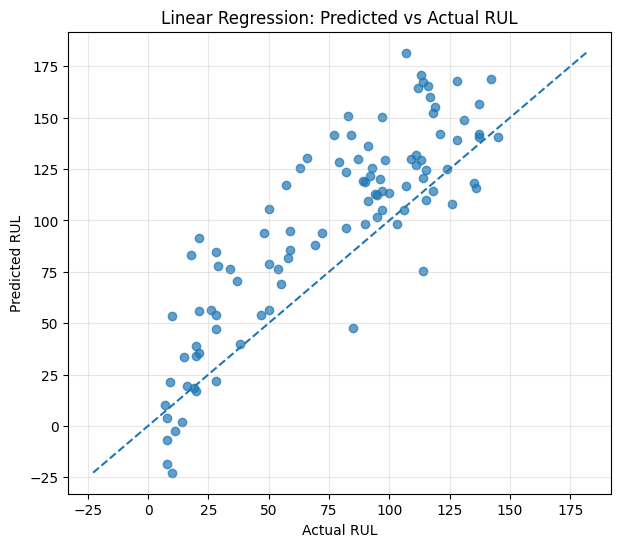

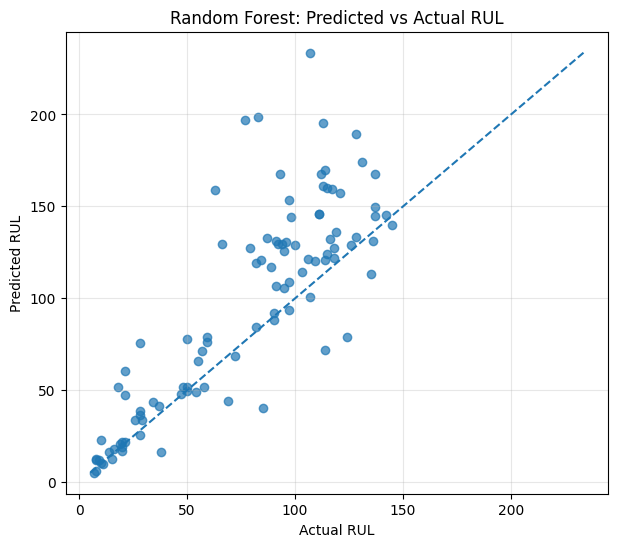

In [27]:
import matplotlib.pyplot as plt


# ============================================================
# 1. LINEAR REGRESSION
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    linear_pred,
    alpha=0.7
)

# Garis prediksi sempurna y = x
min_value = min(y_test.min(), linear_pred.min())
max_value = max(y_test.max(), linear_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression: Predicted vs Actual RUL")

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 2. RANDOM FOREST
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7
)

# Garis prediksi sempurna y = x
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Predicted vs Actual RUL")

plt.grid(alpha=0.3)

plt.show()

## 11. NON-NEGATIVE LINEAR REGRESSION PREDICTION

In [29]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ------------------------------------------------------------
# 1. Koreksi prediksi negatif menjadi 0
# ------------------------------------------------------------

linear_pred_non_negative = np.maximum(
    linear_pred,
    0
)


# ------------------------------------------------------------
# 2. Hitung MAE
# ------------------------------------------------------------

linear_mae_corrected = mean_absolute_error(
    y_test,
    linear_pred_non_negative
)


# ------------------------------------------------------------
# 3. Hitung RMSE
# ------------------------------------------------------------

linear_rmse_corrected = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred_non_negative
    )
)


# ------------------------------------------------------------
# 4. Bandingkan sebelum dan sesudah koreksi
# ------------------------------------------------------------

print("====================================")
print("LINEAR REGRESSION")
print("NON-NEGATIVE CONSTRAINT")
print("====================================")

print("\nBefore correction:")
print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")

print("\nAfter correction:")
print(f"MAE  : {linear_mae_corrected:.2f}")
print(f"RMSE : {linear_rmse_corrected:.2f}")

LINEAR REGRESSION
NON-NEGATIVE CONSTRAINT

Before correction:
MAE  : 26.83
RMSE : 33.00

After correction:
MAE  : 26.33
RMSE : 32.72


## 12. INVESTIGASI UNIT DENGAN ERROR BESAR

UNIT COMPARISON
Worst unit : 78
Best unit  : 38

Worst unit information:
    unit_number  time_cycles  true_RUL  predicted_RUL  absolute_error
77           78           72       107         233.57          126.57

Best unit information:
    unit_number  time_cycles  true_RUL  predicted_RUL  absolute_error
37           38          125        50          49.69            0.31


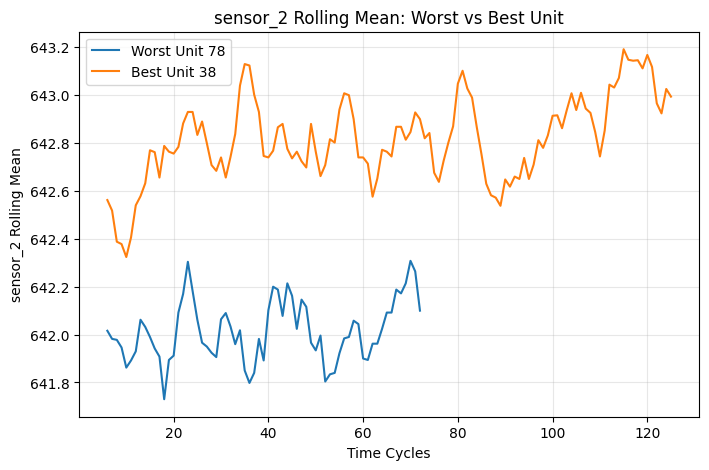

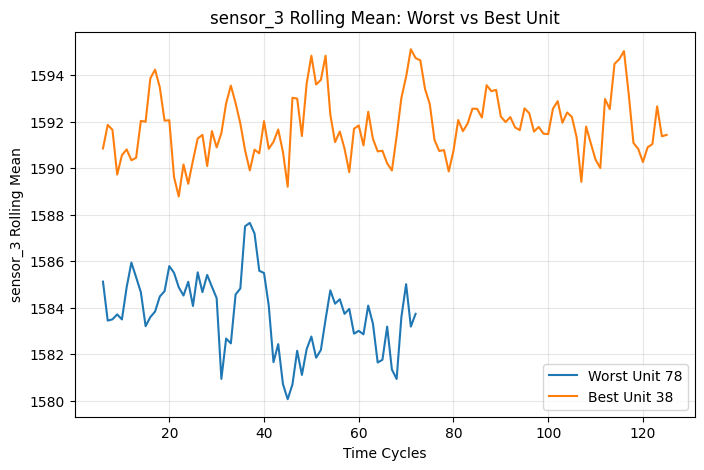

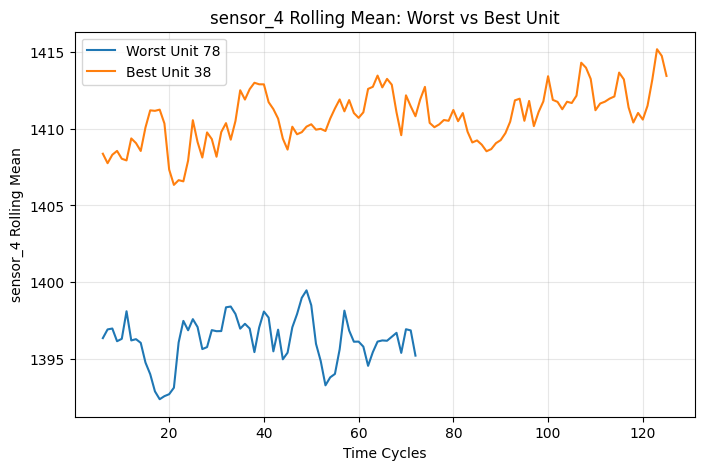

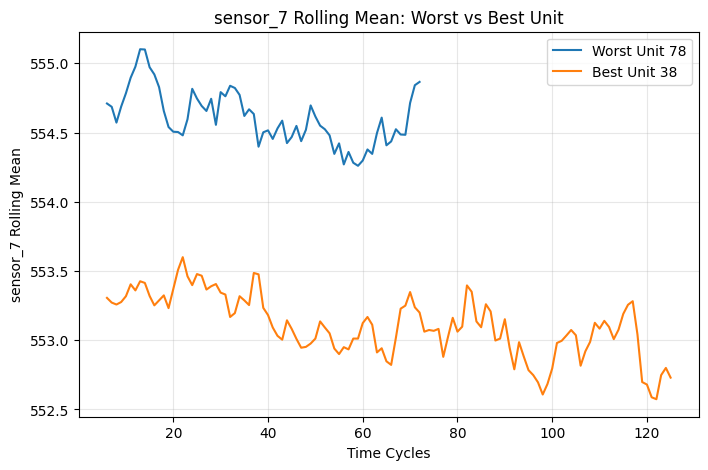

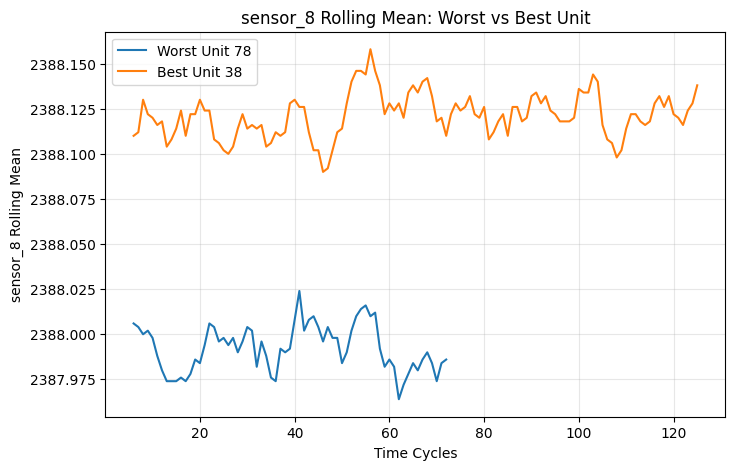

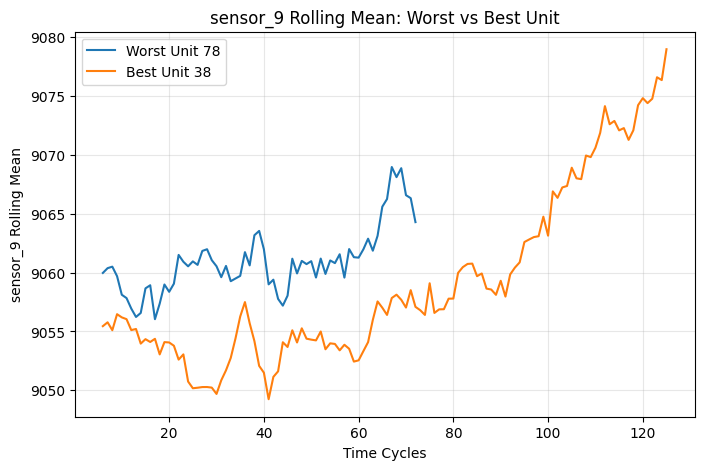

In [30]:
import matplotlib.pyplot as plt


# ============================================================
# 1. BUAT DATA ERROR ANALYSIS
# ============================================================

rf_error_analysis = pd.DataFrame({
    "unit_number": test_evaluation["unit_number"],
    "time_cycles": test_evaluation["time_cycles"],
    "true_RUL": y_test,
    "predicted_RUL": rf_pred
})

rf_error_analysis["absolute_error"] = (
    rf_error_analysis["true_RUL"]
    - rf_error_analysis["predicted_RUL"]
).abs()


# ============================================================
# 2. CARI UNIT TERBURUK DAN UNIT TERBAIK
# ============================================================

worst_unit = (
    rf_error_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .iloc[0]["unit_number"]
)

best_unit = (
    rf_error_analysis
    .sort_values(
        "absolute_error",
        ascending=True
    )
    .iloc[0]["unit_number"]
)


print("====================================")
print("UNIT COMPARISON")
print("====================================")

print("Worst unit :", int(worst_unit))
print("Best unit  :", int(best_unit))


# ============================================================
# 3. TAMPILKAN INFORMASI KEDUA UNIT
# ============================================================

print("\nWorst unit information:")

print(
    rf_error_analysis[
        rf_error_analysis["unit_number"] == worst_unit
    ]
)


print("\nBest unit information:")

print(
    rf_error_analysis[
        rf_error_analysis["unit_number"] == best_unit
    ]
)


# ============================================================
# 4. SENSOR YANG AKAN DIINVESTIGASI
# ============================================================

investigation_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_8",
    "sensor_9"
]


# ============================================================
# 5. AMBIL DATA WORST UNIT
# ============================================================

worst_data = (
    test[
        test["unit_number"] == worst_unit
    ]
    .sort_values("time_cycles")
)


# ============================================================
# 6. AMBIL DATA BEST UNIT
# ============================================================

best_data = (
    test[
        test["unit_number"] == best_unit
    ]
    .sort_values("time_cycles")
)


# ============================================================
# 7. PLOT ROLLING MEAN
# ============================================================

for sensor in investigation_sensors:

    plt.figure(figsize=(8, 5))

    plt.plot(
        worst_data["time_cycles"],
        worst_data[f"{sensor}_roll_mean"],
        label=f"Worst Unit {int(worst_unit)}"
    )

    plt.plot(
        best_data["time_cycles"],
        best_data[f"{sensor}_roll_mean"],
        label=f"Best Unit {int(best_unit)}"
    )

    plt.xlabel("Time Cycles")
    plt.ylabel(f"{sensor} Rolling Mean")

    plt.title(
        f"{sensor} Rolling Mean: "
        f"Worst vs Best Unit"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()